# Location & relocation · Part B: the 2016 Geysers picks

[**Part A**](https://colab.research.google.com/github/AI4EPS/EPS207_Observational_Seismology/blob/main/docs/notebooks/02a_location_method.ipynb) built a world whose answer we planted, and used it to
establish nine things about locating an earthquake. Every one of them was a claim about what real
data would do. This notebook takes the identical code to the 2016 Geysers picks and checks them,
one at a time.

It runs on its own: it loads its own data and defines everything it uses, so Part A does not have
to have been run first. What Part A supplies is the *reasoning* — why each ingredient below is
there, and what it was predicted to do.

The difference between the two halves is that **there is no truth here.** The network published a
catalogue for these earthquakes, but a catalogue is another estimate, not an answer key. So the
question changes shape: instead of "how close are we to the truth?" we can only ask "how close
are we to the network, and does each ingredient move us the way Part A predicted?" A.9 is the
reason we know those are different questions.

## What Part A predicted

These nine statements are the contract. B.8 scores every one of them against what we measure.

| # | what Part A established, in the planted world | established in |
|---|---|---|
| 1 | a coarse search is needed to seed the iteration | A.3, A.4 |
| 2 | depth is the fragile number, and a station closer than the focal depth is what rescues it | A.5 |
| 3 | a robust loss is a large rung of the improvement ladder | A.6 |
| 4 | declared pick weights act mostly on the worst events | A.7 |
| 5 | the quoted errors of a catalogue should be treated as optimistic | A.8, A.9 |
| 6 | a wrong velocity model shows up as depth bias, not as misfit | A.9 |
| 7 | station terms transfer to events they were not fitted on | A.10 |
| 8 | double difference on catalogue-precision picks adds little | A.10 |
| 9 | a 1-D velocity model cannot be fitted with the hypocentres free | A.11 |

## The questions this notebook answers

1. What does a real pick carry besides a time, and which of those fields may we use? (B.1)
2. What does locating one real earthquake look like, end to end? (B.2)
3. Which ingredients actually move a catalogue, and in what order? (B.3)
4. What does a reported depth mean — depth below *what*? (B.4)
5. Do station terms transfer, and what does double difference add on these picks? (B.5, B.6)
6. Which earthquakes can you trust, and does the error bar tell you which? (B.7)
7. Which features of the result may be interpreted, and which belong to the method? (B.8)


In [1]:
import importlib.util
import sys
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The course's modules sit beside the notebook on DataHub; Colab opens the notebook alone, so
# there they are fetched. `geysers_data` reads the release assets; `geysers_loc` is the
# travel-time and solver plumbing Part A worked through, packaged so it can be imported.
BASE = "https://raw.githubusercontent.com/AI4EPS/EPS207_Observational_Seismology/main/docs/notebooks"
for module in ("geysers_data.py", "geysers_loc.py"):
    if "google.colab" in sys.modules or importlib.util.find_spec(module[:-3]) is None:
        for attempt in range(4):
            try:
                urllib.request.urlretrieve(f"{BASE}/{module}", module)
                break
            except Exception as exc:
                if attempt == 3:
                    raise RuntimeError(f"could not fetch {module}: {exc}; re-run this cell") from None
                time.sleep(2 * (attempt + 1))

import geysers_loc as gl

rng = np.random.default_rng(207)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})


## B.1 · The data, and what a pick actually carries

Everything below comes from two public files: the NCEDC routine catalogue for the field, and its
phase picks for 2016. The stations come with `geysers_loc`, so nothing here depends on a web
service answering during class.


In [2]:
from geysers_data import catalog, phases, FIELD

cat = catalog()
cat = cat[cat.longitude.between(*FIELD[:2]) & cat.latitude.between(*FIELD[2:])
          & (cat.year == 2016)].copy()
cat["eid"] = cat.id.astype(str).str.replace("nc", "", regex=False)
cat["x"], cat["y"] = gl.xy(cat.longitude, cat.latitude)
cat["t"] = pd.to_datetime(cat.time, utc=True)
cat = cat.set_index("eid")

sta = gl.stations_2016(within=30.0)
picks = phases(2016).copy()
picks["eid"] = picks.event_id.astype(str)
picks = picks[picks.eid.isin(cat.index) & (picks.distance_km <= 20.0)]
picks = picks.merge(sta[["net", "sta", "x", "y", "z"]], how="inner",
                    left_on=["network", "station"], right_on=["net", "sta"])
picks["ph"] = (picks.phase_type.str.upper() == "S").astype(int)     # 0 = P, 1 = S
picks["tsec"] = (pd.to_datetime(picks.phase_time, utc=True)
                 - picks.eid.map(cat.t)).dt.total_seconds()
picks = picks[picks.tsec.between(-5, 60)]
picks["sta_key"] = picks.network + "." + picks.station + "." + picks.phase_type.str.upper()
n_per = picks.groupby("eid").size()
picks = picks[picks.eid.isin(n_per[n_per >= 8].index)].reset_index(drop=True)
cat = cat.loc[sorted(picks.eid.unique())]

print(f"{len(picks):,} picks on {len(cat):,} earthquakes, at {picks.sta_key.nunique()} "
      f"station-phases ({picks.station.nunique()} stations)")
n = picks.groupby("eid").size()
nP = picks[picks.ph == 0].groupby("eid").size()
nS = picks[picks.ph == 1].groupby("eid").size().reindex(n.index).fillna(0)
print(f"picks per earthquake: median {n.median():.0f}  (P {nP.median():.0f}, S {nS.median():.0f})")
print(f"earthquakes with any S pick: {100 * (nS > 0).mean():.0f} %")


213,345 picks on 9,986 earthquakes, at 92 station-phases (50 stations)
picks per earthquake: median 15  (P 15, S 0)
earthquakes with any S pick: 34 %


### The geometry, against what A.5 said would matter

A.5 established that depth is the fragile quantity, that a station closer than the focal depth is
what rescues it, and that the azimuthal gap is the other thing to watch. So those are the three
numbers to look at first.


In [3]:
d_near = picks.groupby("eid").distance_km.min()
depth = cat.depth.reindex(d_near.index)
print(f"median event depth            {depth.median():.2f} km")
print(f"median nearest station        {d_near.median():.2f} km")
print(f"events with a station closer than their own depth: "
      f"{100 * (d_near < depth).mean():.0f} %")
print(f"median azimuthal gap (catalogue's own): {cat.gap.median():.0f} degrees")
print(f"\nA.5 predicted the dense network is what makes depth usable here, and it is: the")
print("typical earthquake has a station well inside its own focal depth.")


median event depth            1.78 km
median nearest station        0.90 km
events with a station closer than their own depth: 76 %
median azimuthal gap (catalogue's own): 84 degrees

A.5 predicted the dense network is what makes depth usable here, and it is: the
typical earthquake has a station well inside its own focal depth.


### What the network says its own errors are

The catalogue reports an uncertainty per event. These are the numbers we will be compared
against, so it is worth seeing them before we start.


In [4]:
print(f"{'':28}{'median':>9}{'90th pct':>10}")
for lab, col in (("horizontal error (km)", "horizontalError"), ("depth error (km)", "depthError"),
                 ("rms of the fit (s)", "rms")):
    v = cat[col].dropna()
    print(f"{lab:28}{v.median():9.2f}{np.percentile(v, 90):10.2f}")
print(f"\nNote the shape of that: the depth error is about twice the horizontal one, which is")
print("A.5's condition number showing up in the network's own published numbers.")


                               median  90th pct
horizontal error (km)            0.28      0.67
depth error (km)                 0.51      1.28
rms of the fit (s)               0.03      0.07

Note the shape of that: the depth error is about twice the horizontal one, which is
A.5's condition number showing up in the network's own published numbers.


### The anatomy of a pick

A pick is not just a time. Each one carries several other fields, and the distinction between
them turns out to matter more than it looks:

| field | what it is | does it depend on the catalogue's answer? |
|---|---|---|
| `phase_score` | the weight code the analyst assigned when reading the arrival | **no** |
| `phase_remark` | the analyst's description of the onset — impulsive or emergent | **no** |
| `review_status` | whether a human checked it, or it is the automatic pick | **no** |
| `phase_weight` | the weight the network's own location ended up giving it | **yes** |
| `time_residual` | what was left over at this pick in the network's solution | **yes** |

The last column is the one to keep hold of. The first three are judgements made when the arrival
was read, before anybody knew where the earthquake was. The last two are outputs of the
network's inversion. Using the first three is evidence; using the last two to help us reproduce
the catalogue is partly circular, and we will measure how much that matters.


In [5]:
print("what the analyst wrote down at pick time, and how good those picks turned out to be:\n")
print(f"  {'phase_score':>12}{'picks':>10}{'median |resid|':>16}")
for s, g in picks.groupby("phase_score"):
    print(f"  {s:12.2f}{len(g):10,}{g.time_residual.abs().median():16.3f} s")
print(f"\n  {'onset':>12}{'picks':>10}{'median |resid|':>16}")
for r, g in picks.groupby(picks.phase_remark.fillna("(none)")):
    if len(g) > 100:
        print(f"  {r:>12}{len(g):10,}{g.time_residual.abs().median():16.3f} s")
print("\nThe analyst's own labels are informative: a pick they called impulsive really is better")
print("than one they called emergent, and the weight code tracks the eventual residual. This is")
print("A.7's 'declared quality' in the real data, and B.3 uses it as the last rung of the ladder.")


what the analyst wrote down at pick time, and how good those picks turned out to be:

   phase_score     picks  median |resid|
          0.00       100           1.120 s
          0.25    11,913           0.230 s
          0.50    58,655           0.070 s
          0.75    63,934           0.040 s
          1.00    78,743           0.020 s

         onset     picks  median |resid|
        (none)    51,485           0.020 s
             e    58,853           0.050 s
             i   103,006           0.030 s

The analyst's own labels are informative: a pick they called impulsive really is better
than one they called emergent, and the weight code tracks the eventual residual. This is
A.7's 'declared quality' in the real data, and B.3 uses it as the last rung of the ladder.


### The catalogue's own weights, and why we will not lean on them

`phase_weight` is different in kind. It is not a judgement about the waveform — it is the output
of the network's own robust estimation. HYPOINVERSE down-weights a pick whose residual is large
and zeroes it past a cutoff, and the figure below shows that cutoff plainly.


phase_weight runs from 0.00 to 4.74 — it is not a probability
picks given zero weight: 5.8 %, median |residual| 0.790 s against 0.030 s for the rest

        |residual|     picks   zeroed
    0.00- 0.20 s    194,614       0 %
    0.20- 0.25 s      4,484       0 %
    0.25- 0.28 s      1,305       1 %
    0.28- 0.30 s        691      59 %
    0.30- 0.50 s      3,149      93 %
    0.50-20.00 s      9,102      98 %

That is a threshold, not an opinion: below a quarter of a second nothing is discarded,
and past about 0.3 s almost everything is. The catalogue was already doing what A.6 taught,
with a hard cutoff in place of Huber's soft one.


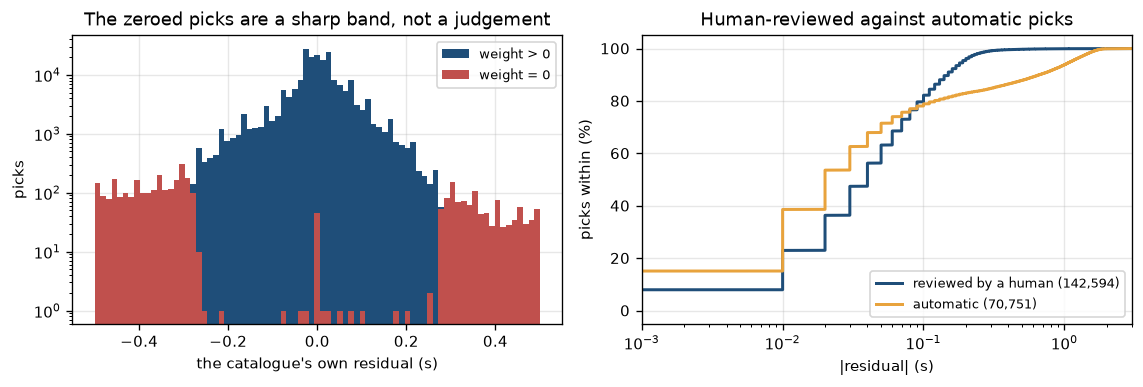

In [6]:
w = picks.phase_weight
r = picks.time_residual.abs()
print(f"phase_weight runs from {w.min():.2f} to {w.max():.2f} — it is not a probability")
print(f"picks given zero weight: {100 * (w == 0).mean():.1f} %, "
      f"median |residual| {r[w == 0].median():.3f} s against {r[w > 0].median():.3f} s for the rest\n")
print(f"  {'|residual|':>16}{'picks':>10}{'zeroed':>9}")
for lo, hi in ((0.0, 0.20), (0.20, 0.25), (0.25, 0.28), (0.28, 0.30), (0.30, 0.50), (0.50, 20.0)):
    m = (r >= lo) & (r < hi)
    print(f"  {lo:6.2f}-{hi:5.2f} s {m.sum():10,}{100 * (w[m] == 0).mean():8.0f} %")
print("\nThat is a threshold, not an opinion: below a quarter of a second nothing is discarded,")
print("and past about 0.3 s almost everything is. The catalogue was already doing what A.6 taught,")
print("with a hard cutoff in place of Huber's soft one.")

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.3))
bins = np.linspace(-0.5, 0.5, 80)
ax[0].hist(picks.loc[w > 0, "time_residual"], bins=bins, color="#1f4e79", label="weight > 0")
ax[0].hist(picks.loc[w == 0, "time_residual"], bins=bins, color="#c0504d", label="weight = 0")
ax[0].set(xlabel="the catalogue's own residual (s)", ylabel="picks", yscale="log",
          title="The zeroed picks are a sharp band, not a judgement")
ax[0].legend(fontsize=8)

man = picks[picks.review_status.astype(str).str.lower().str.startswith("m")]
aut = picks[~picks.index.isin(man.index)]
for lab, g, c in (("reviewed by a human", man, "#1f4e79"), ("automatic", aut, "#e8a33d")):
    v = np.sort(g.time_residual.abs().dropna())
    if len(v):
        ax[1].plot(v, 100 * np.arange(1, len(v) + 1) / len(v), c=c, lw=1.8,
                   label=f"{lab} ({len(g):,})")
ax[1].set(xscale="log", xlim=(1e-3, 3), xlabel="|residual| (s)", ylabel="picks within (%)",
          title="Human-reviewed against automatic picks")
ax[1].legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()


The right-hand panel is the other thing worth noticing, and it prepares session 8. The automatic
picks are *more* precise in the middle — their curve is above the manual one up to about a tenth
of a second — and *worse* in the tail. A machine placing an onset on a clean arrival beats a
human, and a machine placing one on a marginal arrival produces failures a human would not make.
Which of the two locates better therefore depends entirely on the loss function, which is A.6's
whole point arriving in a practical decision.


## B.2 · One earthquake, start to finish

Before any statistic over thousands of events, locate one of them slowly, with everything Part A
built. We take a well-recorded earthquake — plenty of picks, good azimuthal coverage — so that
what we see is the method rather than the data letting us down.


In [7]:
# The travel-time tables Part B uses throughout. `datum` places the model's zero depth at the mean
# station elevation, for the reason B.4 goes into; GIL7 is kept as the "wrong model" of A.9.
# BOTH tables get the same datum, so that swapping one for the other changes the velocity model
# and nothing else. Letting the datum move at the same time would mix two of Part A's factors,
# and B.4 shows that the one we are not testing here is worth a few hundred metres of depth.
DATUM = 0.79
SIGMA = 0.05                              # Huber's scale: A.6's rule is one to two times the
                                          # reading error, and B.3 checks it against these picks
ZS = np.arange(-1.5, 8.01, 0.05)          # source depth, km below sea level
ZR = np.arange(-1.4, 0.21, 0.1)           # station depth (negative = above sea level)
RR = np.arange(0.0, 22.01, 0.05)          # epicentral distance
tab_gey = [gl.build(gl.GEY, ph, ZR, ZS, RR, datum=DATUM) for ph in ("P", "S")]
tab_gil7 = [gl.build(gl.GIL7, ph, ZR, ZS, RR, datum=DATUM) for ph in ("P", "S")]

g = picks.groupby("eid")
score = g.size() - 0.05 * cat.gap.reindex(g.size().index).fillna(180)
EID = score.idxmax()
ev = picks[picks.eid == EID].reset_index(drop=True)
truth_cat = cat.loc[EID]

print(f"event {EID}   M{truth_cat.mag:.1f}   {str(truth_cat.time)[:19]}")
print(f"the catalogue puts it at x {truth_cat.x:+.3f} km, y {truth_cat.y:+.3f} km, "
      f"depth {truth_cat.depth:.2f} km")
print(f"reported uncertainty: {truth_cat.horizontalError:.2f} km horizontal, "
      f"{truth_cat.depthError:.2f} km depth; rms {truth_cat.rms:.3f} s; gap {truth_cat.gap:.0f}°\n")
show = ev.nsmallest(6, "distance_km")[["station", "phase_type", "distance_km", "azimuth",
                                       "phase_score", "phase_remark", "tsec", "time_residual"]]
print(f"{len(ev)} picks; the six nearest:")
print(show.to_string(index=False,
                     formatters={"distance_km": "{:.2f}".format, "azimuth": "{:.0f}".format,
                                 "tsec": "{:.3f}".format, "time_residual": "{:+.3f}".format}))


event 72693501   M2.2   2016-09-10 17:43:05
the catalogue puts it at x +1.790 km, y +4.078 km, depth 1.93 km
reported uncertainty: 0.09 km horizontal, 0.11 km depth; rms 0.060 s; gap 47°

70 picks; the six nearest:
station phase_type distance_km azimuth  phase_score phase_remark  tsec time_residual
    HVC          P        0.70      21         0.75            i 0.430        -0.110
    HVC          S        0.70      21         0.75            i 1.000        +0.040
    CLV          P        1.00     281         0.75            i 0.500        -0.110
    CLV          S        1.00     281         0.75            i 1.070        -0.020
    NEG          P        1.10     130         0.75            i 0.620        -0.030
    NEG          S        1.10     130         0.75            i 1.250        +0.090


### The misfit surface, for a real earthquake

A.2 drew this for a planted event. Here it is for a real one, with the catalogue's answer marked.
The shape is the same: a tight minimum on the map, a long valley in depth.


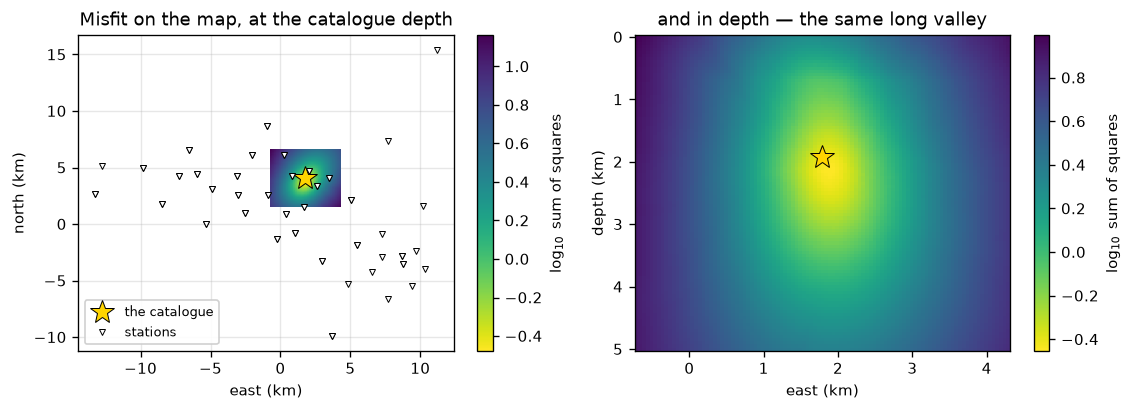

In [8]:
S = ev[["x", "y", "z"]].to_numpy()
t_obs = ev.tsec.to_numpy()
ph = ev.ph.to_numpy()


def misfit_plane(gx, gy, z, tabs, loss="l2"):
    F = np.empty((len(gy), len(gx)))
    for j, y in enumerate(gy):
        r = np.maximum(np.hypot(np.subtract.outer(gx, S[:, 0]), y - S[:, 1]), 1e-3)
        t = np.empty_like(r)
        for q in (0, 1):
            s = ph == q
            if s.any():
                t[:, s] = gl.predict(tabs[q], np.broadcast_to(S[s, 2], (len(gx), int(s.sum()))),
                                     z, r[:, s])[0]
        d = t_obs - t
        F[j] = np.sum(gl.rho(d - np.median(d, axis=1, keepdims=True), loss), axis=1)
    return F


gx = np.linspace(truth_cat.x - 2.5, truth_cat.x + 2.5, 101)
gy = np.linspace(truth_cat.y - 2.5, truth_cat.y + 2.5, 101)
gz = np.linspace(0.0, 5.0, 101)
F_xy = misfit_plane(gx, gy, truth_cat.depth, tab_gey)
F_xz = np.array([misfit_plane(gx, np.array([truth_cat.y]), z, tab_gey)[0] for z in gz])

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.5))
m0 = ax[0].pcolormesh(gx, gy, np.log10(F_xy), cmap="viridis_r", shading="auto")
ax[0].plot(truth_cat.x, truth_cat.y, "*", ms=15, mfc="#ffd400", mec="k", mew=0.6,
           label="the catalogue")
ax[0].plot(S[:, 0], S[:, 1], "v", ms=4, mfc="w", mec="k", mew=0.6, label="stations")
ax[0].set(xlabel="east (km)", ylabel="north (km)", title="Misfit on the map, at the catalogue depth")
ax[0].legend(fontsize=7.5, loc="lower left", framealpha=0.9)
fig.colorbar(m0, ax=ax[0], label=r"$\log_{10}$ sum of squares")
m1 = ax[1].pcolormesh(gx, gz, np.log10(F_xz), cmap="viridis_r", shading="auto")
ax[1].plot(truth_cat.x, truth_cat.depth, "*", ms=15, mfc="#ffd400", mec="k", mew=0.6)
ax[1].invert_yaxis()
ax[1].set(xlabel="east (km)", ylabel="depth (km)", title="and in depth — the same long valley")
fig.colorbar(m1, ax=ax[1], label=r"$\log_{10}$ sum of squares")
fig.tight_layout()
plt.show()


### Locating it, the way A.2 to A.4 said to

Coarse grid search first, because A.4 showed that a damped iteration started from a guess lands
in the wrong basin often enough to matter. Then Levenberg–Marquardt from there.


In [9]:
x0 = gl.grid_search(S, t_obs, ph, tab_gey, half=6.0, step=0.5, zstep=0.5)
out = gl.locate(S, t_obs, ph, tab_gey, x0=x0, loss="huber", sigma=SIGMA)
C = gl.ellipse(out)
sd = np.sqrt(np.diag(C))

print(f"{'':18}{'x':>9}{'y':>9}{'depth':>9}{'t0':>9}{'rms (s)':>10}")
print(f"{'grid search':18}{x0[0]:9.3f}{x0[1]:9.3f}{x0[2]:9.3f}{x0[3]:+9.3f}")
print(f"{'then LM (Huber)':18}{out['m'][0]:9.3f}{out['m'][1]:9.3f}{out['m'][2]:9.3f}"
      f"{out['m'][3]:+9.3f}{out['rms']:10.4f}")
print(f"{'the catalogue':18}{truth_cat.x:9.3f}{truth_cat.y:9.3f}{truth_cat.depth:9.3f}"
      f"{0.0:+9.3f}{truth_cat.rms:10.4f}")
print(f"\nwe land {1000 * np.hypot(out['m'][0] - truth_cat.x, out['m'][1] - truth_cat.y):.0f} m "
      f"horizontally and {1000 * abs(out['m'][2] - truth_cat.depth):.0f} m in depth from the "
      f"catalogue")
print(f"our formal error bar: {1000 * sd[0]:.0f} m east, {1000 * sd[1]:.0f} m north, "
      f"{1000 * sd[2]:.0f} m depth")
print(f"the catalogue's:      {1000 * truth_cat.horizontalError:.0f} m horizontal, "
      f"{1000 * truth_cat.depthError:.0f} m depth")


                          x        y    depth       t0   rms (s)
grid search           1.849    3.584    2.000   -0.052
then LM (Huber)       1.903    3.855    2.071   -0.080    0.0966
the catalogue         1.790    4.078    1.930   +0.000    0.0600

we land 249 m horizontally and 141 m in depth from the catalogue
our formal error bar: 75 m east, 100 m north, 105 m depth
the catalogue's:      90 m horizontal, 110 m depth


### What this one event already shows

**The depth error bar is the big one**, in our solution and in the network's, exactly as A.5's
condition number said it must be — and both codes agree closely about how big it is.

Now change one thing, the velocity model, and watch where the earthquake goes. A.9 predicted a
very specific shape of failure: the depth moves, the epicentre and the fit do not, so nothing
warns you. We test it twice — once with the P picks alone, which is the situation A.9 studied,
and once with the S picks added.


In [10]:
mP = ph == 0
print(f"{'':34}{'east':>8}{'north':>8}{'depth':>8}{'rms (s)':>10}")
for lab, tabs, sel in (("Geysers model, P picks only", tab_gey, mP),
                       ("GIL7 (wrong model), P picks only", tab_gil7, mP),
                       ("Geysers model, P and S", tab_gey, slice(None)),
                       ("GIL7 (wrong model), P and S", tab_gil7, slice(None))):
    o = gl.locate(S[sel], t_obs[sel], ph[sel], tabs, x0=x0, loss="huber", sigma=SIGMA)
    print(f"{lab:34}{o['m'][0]:8.3f}{o['m'][1]:8.3f}{o['m'][2]:8.3f}{o['rms']:10.4f}")
print(f"{'the catalogue':34}{truth_cat.x:8.3f}{truth_cat.y:8.3f}{truth_cat.depth:8.3f}"
      f"{truth_cat.rms:10.4f}")


                                      east   north   depth   rms (s)
Geysers model, P picks only          1.906   3.971   1.773    0.0952
GIL7 (wrong model), P picks only     1.909   3.991   2.769    0.0931
Geysers model, P and S               1.903   3.855   2.071    0.0966
GIL7 (wrong model), P and S          1.404   3.491   2.362    0.2030
the catalogue                        1.790   4.078   1.930    0.0600


**Read the first two rows against each other.** Changing to a velocity model that is wrong for
this field moves the depth by more than eight hundred metres, moves the epicentre by about
forty, and *improves* the misfit by a millisecond. Nothing in the fit objects — the wrong answer
is, if anything, the better-fitting one. If you had only these numbers you would have no way of
telling which of the two to believe, which is precisely what A.9 demonstrated by counting, and
here it is on a single real earthquake.

**Now read the last two rows.** With the S picks included the wrong model is caught at once:
the misfit doubles. The reason is the $V_P/V_S$ ratio: GIL7's varies from layer to layer where
the Geysers model holds it fixed, and an S arrival measures that ratio directly. A.9 separates
the two mechanisms on planted data — forcing GIL7 to a single ratio recovers most of the misfit,
so the ratio error is the larger half and the plain speed error the smaller. So the S picks are
not only A.5's cure for the depth–origin-time trade-off; they are also the thing that makes a
wrong model *visible* instead of silent.

That is worth carrying into B.3, where only a third of events have any S pick at all.


### Does every earthquake need the grid search?

We seeded that location with a coarse search because A.3 found that a damped iteration from a
careless start lands in the wrong basin often enough to matter. That was prediction 1, and it was
measured in a world of planted earthquakes. It is cheap to check here, and the check is worth
more than it looks: the grid search costs about thirty times as much as the iteration it feeds.


In [11]:
many = picks[picks.eid.isin(np.random.default_rng(1).choice(cat.index.values, 400, replace=False))
             ].reset_index(drop=True)


def locate_all(p, how):
    out = []
    for eid, g in p.groupby("eid", sort=False):
        Sg = g[["x", "y", "z"]].to_numpy(); T = g.tsec.to_numpy(); P = g.ph.to_numpy()
        start = (gl.grid_search(Sg, T, P, tab_gey, half=6.0, step=0.5, zstep=0.5) if how == "grid"
                 else [Sg[:, 0].mean(), Sg[:, 1].mean(), 2.0, 0.0])
        r = gl.locate(Sg, T, P, tab_gey, x0=start, loss="huber", sigma=SIGMA,
                      pick_w=g.phase_score.to_numpy())
        out.append((eid, *r["m"], float(np.sqrt(np.mean(r["res"] ** 2)))))
    return pd.DataFrame(out, columns=["eid", "x", "y", "z", "t0", "rms"]).set_index("eid")


fixed, seeded = locate_all(many, "fixed"), locate_all(many, "grid")
ec = cat.loc[fixed.index]
print(f"{'':34}{'median rms':>12}{'from the catalogue':>21}")
for lab, d in (("started at the network centre", fixed), ("started from a grid search", seeded)):
    print(f"{lab:34}{d.rms.median():10.4f} s{np.median(np.hypot(d.x - ec.x, d.y - ec.y)):16.3f} km")
moved = np.hypot(fixed.x - seeded.x, fixed.y - seeded.y)
print(f"\nthe two starts disagree by more than 100 m on {100 * np.mean(moved > 0.1):.0f} % of events,"
      f" and by more than a kilometre on {100 * np.mean(moved > 1.0):.0f} %")
print(f"where they disagree, the grid-seeded answer fits better "
      f"{100 * np.mean((seeded.rms < fixed.rms)[moved > 0.1]):.0f} % of the time")


                                    median rms   from the catalogue
started at the network centre         0.1169 s           0.269 km
started from a grid search            0.1157 s           0.274 km

the two starts disagree by more than 100 m on 12 % of events, and by more than a kilometre on 4 %
where they disagree, the grid-seeded answer fits better 91 % of the time


**Prediction 1 confirmed, and then something Part A did not predict.** The careless start really
does get stuck: on about one earthquake in eight the two procedures end up in different places,
sometimes more than a kilometre apart, and where they differ it is nearly always the grid-seeded
answer that fits the arrival times better. The optimiser does need help.

Now read the last column. **The better-fitting answers are not closer to the catalogue.** Thirty
times the computation buys a real improvement in misfit and no improvement at all in position.

That is the session's central distinction arriving from a third direction. A.9 showed it by
planting a truth; B.2's velocity-model table showed it by making the model wrong; here it turns
up in the optimiser, which is the last place one would look for it. Whenever you find yourself
about to justify a choice by "it fits better", this is the row to remember.


## B.3 · Reproducing the catalogue, one ingredient at a time

Now the population. We locate the same earthquakes five times, adding one ingredient at each
step, and measure how far each answer sits from the network's. Part A predicted the *order* of
these effects; this is the test.

### Scoring it the catalogue's own way

One decision has to be made before any number means anything: what "rms" means. The catalogue
reports one rms per earthquake, weighted, over the picks it kept. Pooling every residual in the
field into a single number is a different and much less stable quantity, because the residuals
are heavy-tailed and a handful of events dominate. We use the catalogue's definition, so that our
rms and its rms are the same kind of thing.


In [12]:
def event_rms(p, res):
    """One rms per event, weighted, over the picks the catalogue kept -- its own definition."""
    k = (p.phase_weight > 0).to_numpy()
    d = pd.DataFrame({"eid": p.eid.to_numpy()[k], "w": p.phase_weight.to_numpy()[k], "r": res[k]})
    return d.groupby("eid").apply(lambda g: np.sqrt(np.sum(g.w * g.r ** 2) / np.sum(g.w)),
                                  include_groups=False)


own = event_rms(picks, picks.time_residual.to_numpy())
print(f"the catalogue's reported rms, median : {cat.rms.median():.4f} s")
print(f"the same events scored our way       : {own.median():.4f} s")
print(f"correlation between the two          : {np.corrcoef(cat.rms.reindex(own.index), own)[0, 1]:.3f}")
print("\nClose enough, and correlated event by event, so the definition is the catalogue's.")


the catalogue's reported rms, median : 0.0300 s
the same events scored our way       : 0.0383 s
correlation between the two          : 0.967

Close enough, and correlated event by event, so the definition is the catalogue's.


### The five rungs

Each row adds one thing and changes nothing else:

1. **GIL7, least squares** — a respectable regional model that is not this field's, and week 1's
   loss. This is the naive answer.
2. **the Geysers model** — the network's own 1-D model, which is Eberhart-Phillips & Oppenheimer
   (1984). Only the velocity model changes: both tables are built on the same datum, so the
   reference surface the depths are measured from is held fixed and B.4 is the only place it moves.
3. **+ station terms** — A.10's correction for the structure under each station.
4. **+ Huber loss** — A.6's robust loss, for the tenth of picks that are badly wrong.
5. **+ the analyst's pick weights** — A.7's declared quality, using `phase_score`, the weight code
   the analyst assigned when reading the arrival.


In [13]:
rng = np.random.default_rng(0)
N_EV = 1200
sub = picks[picks.eid.isin(rng.choice(cat.index.values, N_EV, replace=False))].reset_index(drop=True)
print(f"{sub.eid.nunique():,} earthquakes, {len(sub):,} picks\n")


def relocate(p, tabs, terms=None, loss="l2", sigma=SIGMA, weight_col=None, z0=2.0):
    """Locate every event once. Returns a frame of hypocentres and the per-pick residuals."""
    dt = (np.zeros(len(p)) if terms is None
          else pd.Series(terms).reindex(p.sta_key.to_numpy()).fillna(0.0).to_numpy())
    w = None if weight_col is None else p[weight_col].to_numpy()
    res = np.empty(len(p))
    out = []
    for eid, g in p.groupby("eid", sort=False):
        i = g.index.to_numpy()
        S = g[["x", "y", "z"]].to_numpy()
        r = gl.locate(S, g.tsec.to_numpy(), g.ph.to_numpy(), tabs,
                      x0=[S[:, 0].mean(), S[:, 1].mean(), z0, 0.0], loss=loss, sigma=sigma,
                      terms=dt[i], pick_w=(None if w is None else w[i]))
        res[i] = r["res"]
        out.append((eid, *r["m"]))
    ev = pd.DataFrame(out, columns=["eid", "x", "y", "z", "t0"]).set_index("eid")
    return ev, res


def fit_terms(p, tabs, n_iter=6, **kw):
    """Locate, take the median leftover at each station, subtract, repeat."""
    terms = pd.Series(0.0, index=pd.unique(p.sta_key))
    for _ in range(n_iter):
        _, res = relocate(p, tabs, terms, **kw)
        upd = pd.Series(res, index=p.index).groupby(p.sta_key.to_numpy()).median()
        upd -= upd.mean()              # a common shift is the origin time, not a station term
        terms = terms.add(upd, fill_value=0.0)
    return terms


def score(ev, res, p):
    e = cat.loc[ev.index]
    dh = np.hypot(ev.x - e.x, ev.y - e.y)
    return dict(dh=float(np.median(dh)), dh90=float(np.percentile(dh, 90)),
                dz=float(np.median(ev.z - e.depth)), rms=float(event_rms(p, res).median()))


LADDER = [("GIL7, least squares", tab_gil7, "l2", 0, None),
          ("the Geysers model, least squares", tab_gey, "l2", 0, None),
          ("+ station terms", tab_gey, "l2", 6, None),
          ("+ Huber loss", tab_gey, "huber", 6, None),
          ("+ the analyst's pick weights", tab_gey, "huber", 6, "phase_score")]

rows, results, terms_by = [], {}, {}
print(f"{'':34}{'horiz':>8}{'p90':>8}{'depth':>9}{'rms':>9}")
for label, tabs, loss, n_it, wcol in LADDER:
    t0 = time.time()
    terms = fit_terms(sub, tabs, n_iter=n_it, loss=loss, weight_col=wcol) if n_it else None
    ev, res = relocate(sub, tabs, terms, loss=loss, weight_col=wcol)
    s = score(ev, res, sub)
    results[label], terms_by[label] = ev, terms
    rows.append((label, s))
    print(f"{label:34}{s['dh']:8.3f}{s['dh90']:8.3f}{s['dz']:+9.3f}{s['rms']:9.4f}"
          f"   [{time.time() - t0:.0f}s]")

e = cat.loc[sub.eid.unique()]
print(f"\ncolumns: distance from the catalogue epicentre, its 90th percentile, our depth minus")
print("the catalogue's, and the rms of the fit.\n")
print(f"{'the catalogue states its own error as':44}{e.horizontalError.median():.2f} km "
      f"horizontal, {e.depthError.median():.2f} km depth")
print(f"{'and reports its own rms as':44}{e.rms.median():.4f} s")
print(f"{'which, scored our way, is':44}{event_rms(sub, sub.time_residual.to_numpy()).median():.4f} s")


1,200 earthquakes, 24,626 picks

                                     horiz     p90    depth      rms


GIL7, least squares                  0.638   3.001   +0.453   0.1339   [3s]


the Geysers model, least squares     0.586   3.030   -0.104   0.0927   [3s]


+ station terms                      0.449   2.962   +0.070   0.0642   [20s]


+ Huber loss                         0.217   1.536   +0.228   0.0369   [18s]


+ the analyst's pick weights         0.190   0.612   +0.254   0.0301   [16s]

columns: distance from the catalogue epicentre, its 90th percentile, our depth minus
the catalogue's, and the rms of the fit.

the catalogue states its own error as       0.28 km horizontal, 0.52 km depth
and reports its own rms as                  0.0300 s
which, scored our way, is                   0.0374 s


### What the ladder says, rung by rung

Read it against Part A's predictions.

**The velocity model barely moves the epicentre and moves the depth by half a kilometre.** That
is prediction 6, and it is the row to look at twice. Swapping GIL7 for the field's own model
changes the median horizontal distance by around fifty metres — much the smallest step in that
column — while the depth offset swings from about +0.45 km to roughly zero. A.9 said a wrong
velocity model expresses itself almost entirely as depth bias, and here it is on twenty thousand
real picks.

Note what this rung is *not* doing. Both tables were built on the same datum, so the depth shift
above is the velocity model alone. Had we left GIL7 on its own reference surface, as someone
applying it off the shelf would, the rung would have looked nearly twice as large — half of it
the model and half of it the datum. B.4 separates the two.

**The two robust steps are the largest in horizontal position, and they do different jobs.**
That is predictions 3 and 4, and the ladder separates them cleanly. The cell below turns each
rung into the factor by which it improved the median earthquake and the factor by which it
improved the 90th percentile, which is the only way to see the difference.

**We end up fitting the arrival times better than the catalogue does**, while still sitting a
couple of hundred metres from it. A.9 is why that is not a contradiction: rms measures fit, and
fit is not accuracy.


In [14]:
print(f"{'what the rung added':34}{'median':>9}{'p90':>9}")
for (lab, s), (_, prev) in zip(rows[1:], rows[:-1]):
    print(f"{lab:34}{prev['dh'] / s['dh']:8.2f}x{prev['dh90'] / s['dh90']:8.2f}x")


what the rung added                  median      p90
the Geysers model, least squares      1.09x    0.99x
+ station terms                       1.31x    1.02x
+ Huber loss                          2.07x    1.93x
+ the analyst's pick weights          1.14x    2.51x


**Huber moves the middle; the analyst's weights move the tail.** The robust loss is the largest
single step for the *typical* earthquake, and it improves the 90th percentile by a little less.
The declared weights do almost the reverse: they barely touch the median and cut the 90th
percentile by more than half.

The division of labour is exactly what the two ingredients are for. A robust loss fixes the
ordinary, well-recorded earthquake that happens to carry one bad pick — and most earthquakes are
that. A declared weight is a judgement made before any location existed, and what it rescues is
the event whose picks were poor to begin with, which no loss function can rescue because for
those events there is no majority of good picks to be robust *to*.

This is the same split Part A measured against a planted truth, where a robust loss gained more
on the median than at the tail and declared weights gained more at the tail than on the median.
What is different is the size: the analyst's real labels are worth considerably more at the tail
here than the planted ones were there, which says the weight codes carry information our
synthetic world did not know how to imitate.


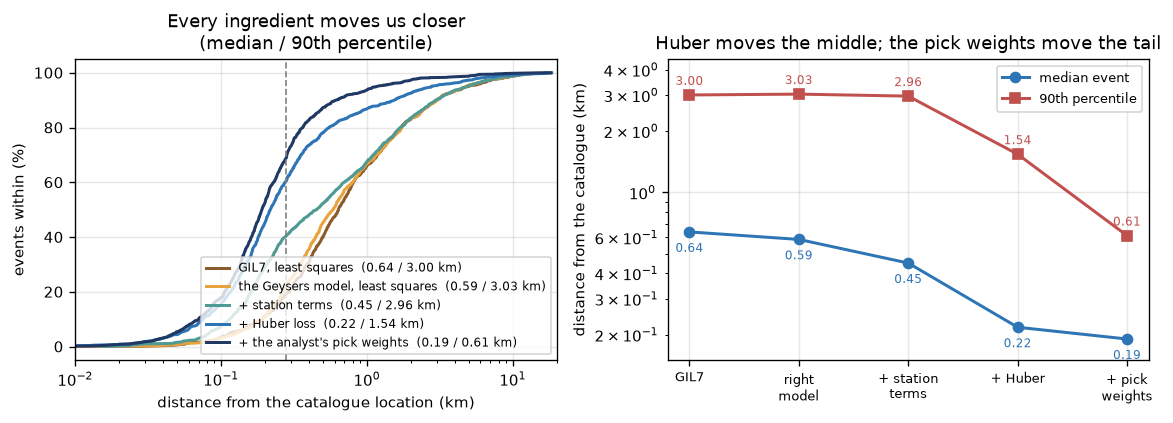

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(9.8, 3.6))
cols = ("#8c5a2b", "#e8a33d", "#4f9a94", "#2e75b6", "#1f3864")
for (label, s), c in zip(rows, cols):
    ev = results[label]
    d = np.sort(np.hypot(ev.x - cat.loc[ev.index].x, ev.y - cat.loc[ev.index].y))
    ax[0].plot(d, 100 * np.arange(1, len(d) + 1) / len(d), c=c, lw=1.8,
               label=f"{label}  ({s['dh']:.2f} / {s['dh90']:.2f} km)")
ax[0].axvline(e.horizontalError.median(), c="0.5", lw=1.0, ls="--")
ax[0].set(xscale="log", xlim=(1e-2, 20), xlabel="distance from the catalogue location (km)",
          ylabel="events within (%)", title="Every ingredient moves us closer\n(median / 90th percentile)")
ax[0].legend(fontsize=7, loc="lower right")

x = np.arange(len(rows))
ax[1].plot(x, [s["dh"] for _, s in rows], "o-", c="#2e75b6", lw=1.8, label="median event")
ax[1].plot(x, [s["dh90"] for _, s in rows], "s-", c="#c0504d", lw=1.8, label="90th percentile")
for i, (_, s) in enumerate(rows):
    ax[1].annotate(f"{s['dh']:.2f}", (i, s["dh"]), (0, -12), textcoords="offset points",
                   ha="center", fontsize=7, color="#2e75b6")
    ax[1].annotate(f"{s['dh90']:.2f}", (i, s["dh90"]), (0, 6), textcoords="offset points",
                   ha="center", fontsize=7, color="#c0504d")
ax[1].set(yscale="log", xticks=x, ylim=(0.15, 4.5), ylabel="distance from the catalogue (km)",
          title="Huber moves the middle; the pick weights move the tail")
ax[1].set_xticklabels(["GIL7", "right\nmodel", "+ station\nterms", "+ Huber", "+ pick\nweights"],
                      fontsize=7.5)
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


### The one number the ladder has not justified

Huber needs a scale. Everything above used `SIGMA`, set in B.2, and A.6 gave the rule for
choosing it: one to two times the reading error, because σ is the residual at which a pick stops
being treated as ordinary noise and starts being treated as suspect. B.1 measured the reading
error of these picks. So the rule is checkable here, on real data, rather than taken on trust.


In [16]:
terms_final = terms_by["+ the analyst's pick weights"]
few = sub[sub.eid.isin(sorted(sub.eid.unique())[:600])].reset_index(drop=True)
print(f"the median |residual| of these picks is {picks.time_residual.abs().median():.3f} s, "
      f"so A.6's rule asks for a sigma near {2 * picks.time_residual.abs().median():.2f} s\n")
print(f"{'Huber sigma':>12}{'median':>10}{'90th pct':>11}{'depth':>9}")
for s_ in (0.03, 0.05, 0.10, 0.20):
    ev_s, _ = relocate(few, tab_gey, terms_final, loss="huber", sigma=s_,
                       weight_col="phase_score")
    es = cat.loc[ev_s.index]
    d = np.hypot(ev_s.x - es.x, ev_s.y - es.y)
    print(f"{s_:12.2f}{np.median(d):10.3f}{np.percentile(d, 90):11.3f}"
          f"{(ev_s.z - es.depth).median():+9.3f}")


the median |residual| of these picks is 0.030 s, so A.6's rule asks for a sigma near 0.06 s

 Huber sigma    median   90th pct    depth


        0.03     0.174      0.545   +0.291


        0.05     0.184      0.565   +0.280


        0.10     0.198      0.744   +0.267


        0.20     0.225      1.292   +0.243


**The rule holds, and it is the tail that cares most.** Across this range the median earthquake
moves by about a third while the 90th percentile more than doubles. A large σ turns Huber back
into least squares — which is A.6's sweep, reproduced on real picks rather than planted ones —
and it is the badly recorded events that pay for it.

Two honest caveats, because this is the kind of table it is easy to over-read. The best
horizontal numbers here are at the *tightest* σ tried, not in the middle of the rule's range; and
the last column moves the other way, because discounting more picks leaves fewer of them to fight
the velocity model's error, and depth is where that error lands. No setting is best at
everything. We keep σ where A.6 put it, inside the rule and matching Part A, and take from the
sweep the direction and the size of the effect rather than a third decimal place.


### Optional: the rung we did not use, and why

There is a sixth ingredient available, and it would make the numbers look better still: the
catalogue's own `phase_weight`. B.1 showed what that field is — the output of the network's own
robust estimation, computed from the residuals of the answer we are trying to reproduce.

Using it is therefore partly circular. We would be told in advance which picks disagree with the
catalogue, and then measured on how close we get to the catalogue. It is worth running once, to
see how large the effect of that circularity is, because the same trap is waiting in any study
that scores itself against a reference product.


In [17]:
terms_h = fit_terms(sub, tab_gey, n_iter=6, loss="huber", weight_col="phase_score")
ev_c, res_c = relocate(sub, tab_gey, terms_h, loss="huber", weight_col="phase_weight")
s_c = score(ev_c, res_c, sub)
print(f"{'':36}{'horiz':>8}{'p90':>8}{'rms':>9}")
print(f"{'the analyst weights (independent)':36}{rows[-1][1]['dh']:8.3f}"
      f"{rows[-1][1]['dh90']:8.3f}{rows[-1][1]['rms']:9.4f}")
print(f"{'the catalogue weights (circular)':36}{s_c['dh']:8.3f}{s_c['dh90']:8.3f}{s_c['rms']:9.4f}")
print("\nThe circular version looks better on every column, and some of that gain is real -- the")
print("catalogue's weights do identify bad picks -- but some of it is simply being handed the")
print("answer. There is no way to separate the two from inside this comparison, which is exactly")
print("why the ladder above stops at the label the analyst wrote down before the event was located.")


                                       horiz     p90      rms
the analyst weights (independent)      0.190   0.612   0.0301
the catalogue weights (circular)       0.175   0.410   0.0267

The circular version looks better on every column, and some of that gain is real -- the
catalogue's weights do identify bad picks -- but some of it is simply being handed the
answer. There is no way to separate the two from inside this comparison, which is exactly
why the ladder above stops at the label the analyst wrote down before the event was located.


## B.4 · What a depth actually means here

B.3's ladder moved the whole catalogue a kilometre in depth by changing the velocity model. That
should make you uneasy about the word "depth", because the field's central scientific claim *is*
a depth claim: the seismicity is said to outline the producing reservoir, roughly 0.5 to 3 km
below sea level. A systematic error of a few hundred metres would change what that sentence says.

So this section asks a question that sounds pedantic and is not: **depth below what?**

### The network is spread over a mountain

The Geysers is a geothermal field in the Coast Ranges, and its stations are not on a plane.


In [18]:
sub = picks[picks.eid.isin(np.random.default_rng(0).choice(cat.index.values, 600,
                                                           replace=False))].reset_index(drop=True)
st = gl.stations_2016(within=20.0)
elev = -st.z * 1000
print(f"{len(st)} stations, elevations {elev.min():.0f} to {elev.max():.0f} m above sea level "
      f"(a spread of {elev.max() - elev.min():.0f} m)")
print(f"mean station elevation: {elev.mean():.0f} m")
print(f"median earthquake depth below sea level: {cat.depth.median():.2f} km")
print(f"\nSo the relief across the network is about "
      f"{100 * (elev.max() - elev.min()) / 1000 / cat.depth.median():.0f} % of a typical event depth.")
top, v = gl.layers(gl.GEY, "P")
print(f"at the surface velocity of {v[0]:.2f} km/s, a kilometre of elevation is worth "
      f"{1000 / v[0]:.0f} ms of travel time")


77 stations, elevations 82 to 1309 m above sea level (a spread of 1227 m)
mean station elevation: 785 m
median earthquake depth below sea level: 1.78 km

So the relief across the network is about 69 % of a typical event depth.
at the surface velocity of 4.43 km/s, a kilometre of elevation is worth 226 ms of travel time


### What HYPOINVERSE does about it, and what that implies

The catalogue was made with HYPOINVERSE using a `CRH` crustal model. Its manual is explicit: such
a model *"assumes stations to be at the earth's surface"* and *"station elevations are not used"*,
so the depths it reports are **relative to the average local surface defined by nearby stations**,
not to sea level.

That means there is a datum buried in the catalogue, and it is roughly the mean station elevation.
We can test the consequence directly: locate the same earthquakes with the model's zero depth
placed at several different elevations, and see what moves.


In [19]:
print(f"{'model datum':>14}{'median depth':>14}{'vs catalogue':>14}{'horiz':>9}{'rms':>9}")
res_by_datum, terms_by_datum = {}, {}
for datum in (0.0, 0.40, 0.79, 1.20):
    tabs = [gl.build(gl.GEY, ph, ZR, ZS, RR, datum=datum) for ph in ("P", "S")]
    terms = pd.Series(0.0, index=pd.unique(sub.sta_key))
    for _ in range(6):
        _, r = relocate(sub, tabs, terms, loss="huber", weight_col="phase_score")
        u = pd.Series(r, index=sub.index).groupby(sub.sta_key.to_numpy()).median()
        u -= u.mean()
        terms = terms.add(u, fill_value=0.0)
    ev, r = relocate(sub, tabs, terms, loss="huber", weight_col="phase_score")
    e = cat.loc[ev.index]
    res_by_datum[datum], terms_by_datum[datum] = ev, terms
    print(f"{datum:12.2f} km{ev.z.median():14.3f}{(ev.z - e.depth).median():+14.3f}"
          f"{np.median(np.hypot(ev.x - e.x, ev.y - e.y)):9.3f}{event_rms(sub, r).median():9.4f}")


   model datum  median depth  vs catalogue    horiz      rms


        0.00 km         2.260        +0.539    0.206   0.0307


        0.40 km         2.177        +0.436    0.197   0.0309


        0.79 km         2.051        +0.292    0.205   0.0313


        1.20 km         1.892        +0.168    0.211   0.0313


**The datum moves the depth and leaves everything else alone.** Across that range the median
depth shifts by hundreds of metres, while the epicentre and the rms barely change. The arrival
times cannot tell you which datum is right: a different reference surface is absorbed almost
perfectly by the origin times.

This is the same null space A.11 showed between depth and velocity, wearing different clothes.
And it has a direct scientific consequence: **a reported depth is meaningless without the datum
it was measured from**, and the difference between plausible choices here is comparable to the
thickness of the reservoir the depths are used to outline.

### Does the model want the stations at their true elevation, or flattened?

There is a second, related question. We *can* put the stations at their real elevations, because
our travel-time model extends above sea level. HYPOINVERSE's `CRH` cannot. Which fits better?


In [20]:
print(f"{'':44}{'median depth':>14}{'horiz':>9}{'rms':>9}")
for lab, datum, flatten in (("true elevations, datum at mean station height", 0.79, False),
                            ("true elevations, datum at sea level", 0.00, False),
                            ("stations flattened onto the model top", 0.79, True)):
    tabs = [gl.build(gl.GEY, ph, ZR, ZS, RR, datum=datum) for ph in ("P", "S")]
    p2 = sub.copy()
    if flatten:
        p2["z"] = 0.0
    terms = pd.Series(0.0, index=pd.unique(p2.sta_key))
    for _ in range(6):
        _, r = relocate(p2, tabs, terms, loss="huber", weight_col="phase_score")
        u = pd.Series(r, index=p2.index).groupby(p2.sta_key.to_numpy()).median()
        u -= u.mean()
        terms = terms.add(u, fill_value=0.0)
    ev, r = relocate(p2, tabs, terms, loss="huber", weight_col="phase_score")
    e = cat.loc[ev.index]
    print(f"{lab:44}{ev.z.median():14.3f}{np.median(np.hypot(ev.x - e.x, ev.y - e.y)):9.3f}"
          f"{event_rms(p2, r).median():9.4f}")
print(f"\nthe catalogue's own median depth: {cat.depth.reindex(sub.eid.unique()).median():.3f} km")


                                              median depth    horiz      rms


true elevations, datum at mean station height         2.051    0.205   0.0313


true elevations, datum at sea level                  2.260    0.206   0.0307


stations flattened onto the model top                2.563    0.242   0.0317

the catalogue's own median depth: 1.765 km


Flattening the stations — throwing away the topography the way a `CRH` model must — pushes the
median depth down by several hundred metres and costs almost nothing in rms. Once again the data
barely object.

### Why this matters for the science

Put the numbers beside the claim they are used to support.


our depths, datum at the mean station elevation:
   10th percentile   0.41 km
   25th percentile   1.31 km
   50th percentile   2.05 km
   75th percentile   2.76 km
   90th percentile   3.51 km

fraction between 0.5 and 3 km below sea level: 68 %
the datum choice alone moves the median depth by 0.37 km,
against a reservoir said to be about 2.5 km thick.


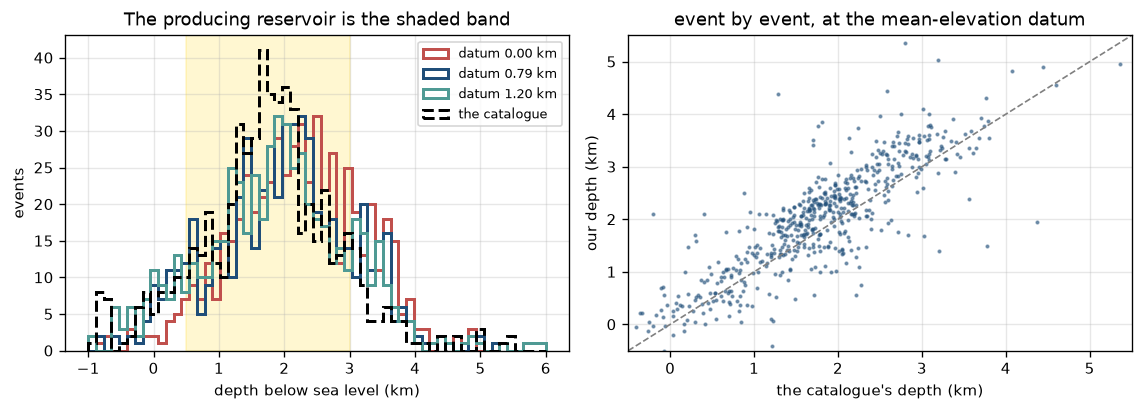

In [21]:
ev = res_by_datum[0.79]
depth = ev.z
print(f"our depths, datum at the mean station elevation:")
for q in (10, 25, 50, 75, 90):
    print(f"   {q:2d}th percentile {np.percentile(depth, q):6.2f} km")
inside = np.mean((depth > 0.5) & (depth < 3.0))
print(f"\nfraction between 0.5 and 3 km below sea level: {100 * inside:.0f} %")
shift = res_by_datum[0.0].z.median() - res_by_datum[1.20].z.median()
print(f"the datum choice alone moves the median depth by {abs(shift):.2f} km,")
print(f"against a reservoir said to be about 2.5 km thick.")

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.5))
bins = np.linspace(-1, 6, 60)
for datum, c in zip((0.0, 0.79, 1.20), ("#c0504d", "#1f4e79", "#4f9a94")):
    ax[0].hist(res_by_datum[datum].z, bins=bins, histtype="step", lw=1.8, color=c,
               label=f"datum {datum:.2f} km")
ax[0].hist(cat.depth.reindex(ev.index), bins=bins, histtype="step", lw=1.8, color="k",
           ls="--", label="the catalogue")
ax[0].axvspan(0.5, 3.0, color="#ffd400", alpha=0.18, zorder=0)
ax[0].set(xlabel="depth below sea level (km)", ylabel="events",
          title="The producing reservoir is the shaded band")
ax[0].legend(fontsize=7.5)

ax[1].plot(cat.depth.reindex(ev.index), ev.z, ".", ms=3, c="#1f4e79", alpha=0.5)
lim = [-0.5, 5.5]
ax[1].plot(lim, lim, c="0.5", lw=1.0, ls="--")
ax[1].set(xlim=lim, ylim=lim, xlabel="the catalogue's depth (km)", ylabel="our depth (km)",
          title="event by event, at the mean-elevation datum")
fig.tight_layout()
plt.show()


**The conclusion is not that the published depths are wrong.** It is that a depth is a statement
about a reference surface, and this field's reference surface sits the better part of a kilometre
above sea level. Anyone comparing these hypocentres with a well trajectory, a reservoir model or
a tomographic image has to establish which datum each uses before the comparison means anything —
and the size of the mistake available here is comparable to the structure being argued about.


### The same freedom, in the velocity model

The datum is one way to move every depth at once without upsetting the arrival times. A.11 found
a second, and it is the one prediction of Part A that we have not yet been able to test: **push
every earthquake deeper and slow the velocity model to match, and the data barely notice.**

That experiment needs no truth, so unlike coverage it *can* be run on real picks. We take the
solution at the mean-elevation datum, push every hypocentre down by a fixed amount, and then ask
the velocity model to do its best: scale every layer by one common factor, chosen to fit the
2016 arrival times as well as possible. If depth and velocity were separable, pushing the
earthquakes down would ruin the fit and no rescaling would rescue it.


In [22]:
ev79, terms79 = res_by_datum[0.79], terms_by_datum[0.79]
small = sub[sub.eid.isin(ev79.index[:250])].reset_index(drop=True)
dt79 = pd.Series(terms79).reindex(small.sta_key.to_numpy()).fillna(0.0).to_numpy()
trade = {}
for scale in np.arange(0.94, 1.0601, 0.03):
    mod = gl.GEY.copy()
    mod[:, 1:] *= scale                       # one common factor on every layer, P and S alike
    tb = [gl.build(mod, ph, ZR, ZS, RR, datum=0.79) for ph in ("P", "S")]
    for push in (0.0, 0.2, 0.4, 0.6):
        rr = []
        for eid, g in small.groupby("eid", sort=False):
            i = g.index.to_numpy()
            m = np.array([ev79.x[eid], ev79.y[eid], ev79.z[eid] + push, ev79.t0[eid]])
            d = gl.residuals(g[["x", "y", "z"]].to_numpy(), g.tsec.to_numpy(), g.ph.to_numpy(),
                             tb, m, terms=dt79[i])
            rr.append(d - np.median(d))       # the origin time absorbs any constant shift
        v = float(np.median(np.abs(np.concatenate(rr))))
        if v < trade.get(push, (np.inf, None))[0]:
            trade[push] = (v, scale)

print(f"{'every event pushed deeper by':>30}{'best velocity scaling':>24}{'median |residual|':>20}")
for push, (v, scale) in trade.items():
    print(f"{push:26.1f} km{scale:24.2f}{v:18.4f} s")


  every event pushed deeper by   best velocity scaling   median |residual|
                       0.0 km                    1.00            0.0210 s
                       0.2 km                    0.97            0.0225 s
                       0.4 km                    0.97            0.0239 s
                       0.6 km                    0.94            0.0255 s


**Prediction 9 confirmed on real data**, with a caveat worth having. Pushing every earthquake in
the field six hundred metres deeper, and letting the model slow by six per cent to compensate,
costs about four milliseconds on the median residual; two hundred metres costs about one, which
is well under the disagreement between two analysts reading the same arrival. The times are not
perfectly indifferent to the trade — they resist it slightly more than Part A's cleaner world
did — but they are indifferent enough that no amount of fitting will settle it for you.

This is why a 1-D velocity model is never fitted with the hypocentres free, and why programs
that do fit one — VELEST is the classic — need external information to break the tie: a shot
with a known origin time and location, a fixed station, or a layer held at a published value.
It is also the second half of the answer to "depth below what?". The first half was the datum;
this is the velocity model, and between them they set how far a published depth can move while
the residuals stay silent.


## B.5 · Do the station terms mean anything?

A station term improved the ladder, but that is not by itself evidence that it is real. With one
free parameter per station and thousands of events we could be fitting noise. A.10 planted the
delays and checked the recovered terms against them; here there is nothing to check against, so
we have to ask the question the way week 1 taught: **does it transfer?**

Fit the terms on one set of earthquakes, apply them unchanged to a completely different set, and
see whether they still help. If a station term is a property of the station, it will. If it is a
property of the events we happened to fit, it will not.

### Fitted on one half of the catalogue, applied to the other


In [23]:
def dh(ev):
    """Median distance from the catalogue epicentre, in km."""
    e = cat.loc[ev.index]
    return float(np.median(np.hypot(ev.x - e.x, ev.y - e.y)))


rng = np.random.default_rng(1)
ids = rng.permutation(cat.index.values)[:1600]
A_ids, B_ids = ids[:800], ids[800:]
pA = picks[picks.eid.isin(A_ids)].reset_index(drop=True)
pB = picks[picks.eid.isin(B_ids)].reset_index(drop=True)
print(f"set A: {pA.eid.nunique()} events, {len(pA):,} picks")
print(f"set B: {pB.eid.nunique()} events, {len(pB):,} picks   (no overlap)\n")

terms_A = fit_terms(pA, tab_gey, loss="huber", weight_col="phase_score")
terms_B = fit_terms(pB, tab_gey, loss="huber", weight_col="phase_score")

ev_none, _ = relocate(pB, tab_gey, None, loss="huber", weight_col="phase_score")
ev_self, _ = relocate(pB, tab_gey, terms_B, loss="huber", weight_col="phase_score")
ev_xfer, _ = relocate(pB, tab_gey, terms_A, loss="huber", weight_col="phase_score")
print("locating set B, with terms fitted on:")
print(f"   nothing                          {dh(ev_none):.3f} km from the catalogue")
print(f"   set B itself (in-sample)         {dh(ev_self):.3f} km")
print(f"   set A (never seen these events)  {dh(ev_xfer):.3f} km")
common = terms_A.index.intersection(terms_B.index)
nA = pA.groupby("sta_key").size().reindex(common).fillna(0)
print(f"\nhow well the two independent sets of terms agree, by how many picks the station had:")
print(f"   {'picks at the station':>24}{'stations':>10}{'correlation':>13}")
for lo in (0, 10, 50, 200):
    k = common[nA >= lo]
    if len(k) > 3:
        print(f"   {'at least ' + str(lo):>24}{len(k):10d}{np.corrcoef(terms_A[k], terms_B[k])[0, 1]:13.3f}")
big = common[nA >= 50]
print(f"\non the well-sampled stations the two fits differ by a median of "
      f"{np.median(np.abs(terms_A[big] - terms_B[big])):.3f} s,")
print(f"against a spread across stations of {terms_B[big].std():.3f} s")


set A: 800 events, 17,228 picks
set B: 800 events, 17,533 picks   (no overlap)



locating set B, with terms fitted on:
   nothing                          0.281 km from the catalogue
   set B itself (in-sample)         0.206 km
   set A (never seen these events)  0.196 km

how well the two independent sets of terms agree, by how many picks the station had:
       picks at the station  stations  correlation
                 at least 0        86        0.450
                at least 10        80        0.959
                at least 50        58        0.997
               at least 200        37        0.998

on the well-sampled stations the two fits differ by a median of 0.029 s,
against a spread across stations of 0.084 s


**Out of sample is as good as in sample.** Terms fitted on eight hundred earthquakes work just as
well on eight hundred different ones. That is prediction 7, and it is the reason station terms
are worth doing at all: a quantity that transfers can be measured once and reused.

**But look at how the agreement depends on sampling.** Across all stations the two independent
fits correlate only moderately; restricted to stations with a decent number of picks they agree
almost perfectly. A station term is an average, and an average over a handful of events is mostly
noise. The terms are real where the data are there to determine them, and invented where they
are not — which is worth remembering before reading a map of station corrections.

### What a station term turns out to be a measurement of


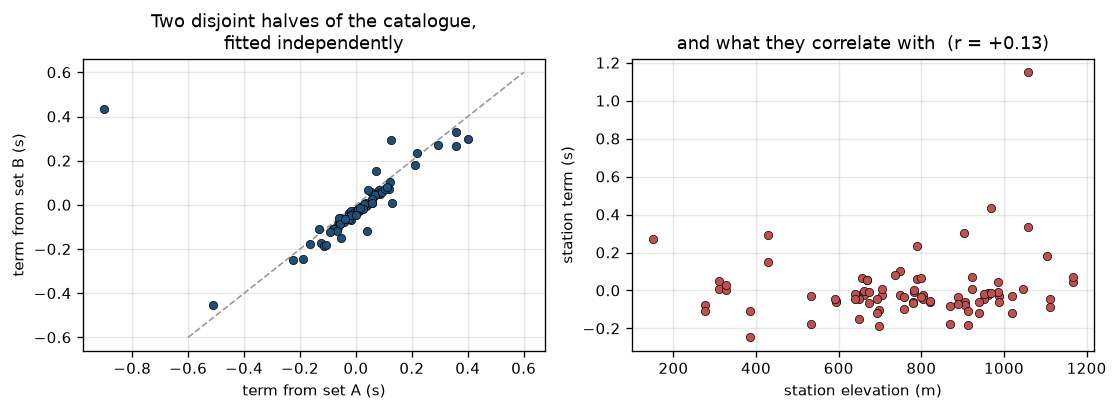

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.5))
common = terms_A.index.intersection(terms_B.index)
ax[0].plot([-0.6, 0.6], [-0.6, 0.6], c="0.6", lw=1.0, ls="--")
ax[0].plot(terms_A[common], terms_B[common], "o", ms=5, mfc="#1f4e79", mec="k", mew=0.4)
ax[0].set(xlabel="term from set A (s)", ylabel="term from set B (s)",
          title="Two disjoint halves of the catalogue,\nfitted independently")

sta = gl.stations_2016(within=20.0).set_index("sta")
key_sta = pd.Series(terms_B.index.str.split(".").str[1], index=terms_B.index)
el = key_sta.map(-sta.z * 1000)
ok = el.notna()
ax[1].plot(el[ok], terms_B[ok], "o", ms=5, mfc="#c0504d", mec="k", mew=0.4)
ax[1].set(xlabel="station elevation (m)", ylabel="station term (s)",
          title=f"and what they correlate with  (r = {np.corrcoef(el[ok], terms_B[ok])[0, 1]:+.2f})")
fig.tight_layout()
plt.show()


## B.6 · Double difference, and the limit the picks impose

A.10 built the double-difference system and found something that contradicts the method's
reputation: on picks of catalogue precision it adds very little, because differencing two picks
each uncertain by a few hundredths of a second gives a differential time that is *noisier* than
either. The gain came only when the differential times were measured by cross-correlation.

Catalogue picks are all we have until session 6, so this is a fair test of that prediction. Take
the densest cluster in the field — where the cancellation argument is strongest — and try.


In [25]:
from scipy.spatial import cKDTree                 # to find the tightest knot of seismicity
from scipy.sparse import csr_matrix               # the design matrix is mostly zeros
from scipy.sparse.linalg import lsqr

# Where to look is not the measurement, so the catalogue's own hypocentres may be used to choose
# the cluster: it costs us nothing to let it point at the densest part of the field.
P = np.column_stack([cat.x, cat.y, cat.depth])
ball = cKDTree(P).query_ball_point(P, 0.5)
core = int(np.argmax([len(b) for b in ball]))
sel = cat.index.values[ball[core]]

pc = picks[picks.eid.isin(sel)].reset_index(drop=True)
M0, _ = relocate(pc, tab_gey, terms_A, loss="huber", weight_col="phase_score")
order = list(M0.index)
M_start = M0.loc[order, ["x", "y", "z", "t0"]].to_numpy()
print(f"the densest knot in the field: {len(order)} earthquakes inside a 500 m ball at "
      f"({P[core][0]:+.2f}, {P[core][1]:+.2f}, {P[core][2]:.2f}) km")
print(f"{len(pc):,} picks, a median of {pc.groupby('eid').size().median():.0f} per earthquake")


the densest knot in the field: 435 earthquakes inside a 500 m ball at (-2.47, +4.50, 1.57) km
7,330 picks, a median of 14 per earthquake


### The system, one pair at a time

The double-difference equation is the ordinary location equation with one event subtracted from
another. For a pair $i, j$ recorded at the same station, the datum is the difference of their
residuals, and the unknowns are *both* hypocentres — so each row carries eight non-zero entries,
four with the sign of event $i$ and four with the sign of event $j$. Everything that is common
to the two ray paths — the wrong velocity model, the structure under that station — subtracts
out, and that cancellation is the entire idea of Waldhauser & Ellsworth (2000).


In [26]:
def rows_for(m, S, ph):
    """The same Jacobian as A.2, evaluated for one event at one set of stations."""
    dx, dy = m[0] - S[:, 0], m[1] - S[:, 1]
    r = np.maximum(np.hypot(dx, dy), 1e-3)
    t = np.empty_like(r); p = np.empty_like(r); eta = np.empty_like(r)
    for q in (0, 1):
        s = ph == q
        if s.any():
            t[s], p[s], eta[s] = gl.predict(tab_gey[q], S[s, 2], m[2], r[s])
    return t, np.column_stack([p * dx / r, p * dy / r, eta, np.ones_like(r)])


ev_data = {e: (g[["x", "y", "z"]].to_numpy(), g.tsec.to_numpy(), g.ph.to_numpy(),
               g.sta_key.to_numpy()) for e, g in pc.groupby("eid")}
D = np.linalg.norm(M_start[:, None, :3] - M_start[None, :, :3], axis=2)
np.fill_diagonal(D, np.inf)
near = sorted({(min(i, j), max(i, j)) for i in range(len(M_start)) for j in np.argsort(D[i])[:8]})

# Which stations a pair has in common never changes, so it is worked out once here rather than
# inside every sweep of every solve.
PAIR = []
for i, j in near:
    Si, ti, phi, ki = ev_data[order[i]]
    Sj, tj, phj, kj = ev_data[order[j]]
    shared = np.intersect1d(ki, kj)
    if len(shared) < 4:                       # too few common stations to constrain a pair
        continue
    ai = np.array([int(np.where(ki == s)[0][0]) for s in shared])
    aj = np.array([int(np.where(kj == s)[0][0]) for s in shared])
    PAIR.append((i, j, Si[ai], ti[ai], phi[ai], Sj[aj], tj[aj], phj[aj]))
sep = float(np.median([D[i, j] for i, j, *_ in PAIR]))
print(f"{len(PAIR):,} neighbouring pairs, median separation {1000 * sep:.0f} m")
print(f"{sum(len(q[3]) for q in PAIR):,} differential times")


2,306 neighbouring pairs, median separation 146 m
23,378 differential times


In [27]:
def double_difference(M, damp, sweeps=5):
    """Waldhauser & Ellsworth's system: damped least squares on differences of residuals."""
    M = M.copy()
    for _ in range(sweeps):
        rows, cols, vals, rhs = [], [], [], []
        for i, j, Si, ti, phi, Sj, tj, phj in PAIR:
            Ti, Gi = rows_for(M[i], Si, phi)
            Tj, Gj = rows_for(M[j], Sj, phj)
            d = (ti - M[i, 3]) - (tj - M[j, 3]) - (Ti - Tj)
            for k in range(len(d)):
                r = len(rhs)
                for c in range(4):
                    rows += [r, r]; cols += [4 * i + c, 4 * j + c]
                    vals += [Gi[k, c], -Gj[k, c]]
                rhs.append(d[k])
        rhs = np.array(rhs)
        A = csr_matrix((vals, (rows, cols)), shape=(len(rhs), 4 * len(M)))
        dm = lsqr(A, rhs, damp=damp)[0].reshape(len(M), 4)
        dm[:, :3] -= dm[:, :3].mean(axis=0)   # DD cannot move the cluster as a whole
        M = M + dm
    return M


def dd_rms(M):
    """The differential times DD is trying to drive to zero -- its own measure of success."""
    d = []
    for i, j, Si, ti, phi, Sj, tj, phj in PAIR:
        Ti, _ = rows_for(M[i], Si, phi)
        Tj, _ = rows_for(M[j], Sj, phj)
        d.append((ti - M[i, 3]) - (tj - M[j, 3]) - (Ti - Tj))
    return float(np.sqrt(np.mean(np.concatenate(d) ** 2)))


def spread(A):
    """Two numbers: how big the cluster is, and how far apart the neighbouring pairs are."""
    return (1000 * np.median(np.linalg.norm(A[:, :3] - A[:, :3].mean(axis=0), axis=1)),
            1000 * np.median([np.linalg.norm(A[i, :3] - A[j, :3]) for i, j, *_ in PAIR]))


print(f"{'damping':>10}{'cluster radius':>16}{'pair separation':>18}{'differential rms':>19}")
a0, b0 = spread(M_start)
print(f"{'(start)':>10}{a0:13.0f} m{b0:15.0f} m{dd_rms(M_start):16.4f} s")
runs = {}
for damp in (1.0, 10.0, 50.0):
    runs[damp] = M = double_difference(M_start, damp)
    a, b = spread(M)
    print(f"{damp:10.1f}{a:13.0f} m{b:15.0f} m{dd_rms(M):16.4f} s")


   damping  cluster radius   pair separation   differential rms


   (start)          452 m            146 m          0.3908 s


       1.0         1154 m           1870 m          0.3189 s


      10.0          450 m            172 m          0.3660 s


      50.0          452 m            146 m          0.3833 s


### The better fit is the worse answer

Read that table across rather than down. **Weak damping gives the best fit in the last column
and by far the worst geometry in the other two.** It improves the differential misfit by about a
sixth — a real, measurable improvement in what the method is minimising — and in doing so it
drags neighbouring earthquakes ten times further apart than they started. Heavy damping leaves
the cluster exactly as it found it. There is no setting in between that sharpens anything.

Two separate things are happening here, and both are worth carrying away.

**The first is the loss function, for the third time this session.** Our system is plain damped
least squares, so one badly wrong differential time pulls with its full weight — and a
differential rms of a third of a second says there are plenty of those. This is not what HypoDD
does: it re-weights by residual and by event separation between sweeps, which is exactly A.6's
lesson applied to pairs instead of picks. Undamped, our version fails the way A.6's L2 fit
failed, and for the same reason.

**The second is that there is nothing for it to find**, however it is weighted. A differential
time built from two analyst picks inherits both their errors. Convert that timing error into a
distance at the local velocity and you get the separation the measurement can actually resolve:


In [28]:
top, v = gl.layers(gl.GEY, "P")
sig_pick = picks.time_residual.abs().median()
print(f"typical pick error                       {sig_pick:.3f} s")
print(f"so a differential time is uncertain by   {sig_pick * np.sqrt(2):.3f} s")
print(f"at {v[0]:.1f} km/s that is a distance of      "
      f"{1000 * sig_pick * np.sqrt(2) * v[0]:.0f} m")
print(f"\nand the pairs we are trying to resolve are {1000 * sep:.0f} m apart.")
print("\nThe noise is LARGER than the signal. There is nothing in these differential times")
print("about the relative positions of earthquakes this close together, which is why no")
print("amount of damping extracts any -- and why loosening the damping can only fit noise.")
print(f"\nWith cross-correlation times at 0.003 s the same arithmetic gives "
      f"{1000 * 0.003 * np.sqrt(2) * v[0]:.0f} m,")
print("which is an order of magnitude inside the cluster -- and that is the whole reason HypoDD")
print("and GrowClust are run on correlation data. Session 6 measures those times.")


typical pick error                       0.030 s
so a differential time is uncertain by   0.042 s
at 4.4 km/s that is a distance of      188 m

and the pairs we are trying to resolve are 146 m apart.

The noise is LARGER than the signal. There is nothing in these differential times
about the relative positions of earthquakes this close together, which is why no
amount of damping extracts any -- and why loosening the damping can only fit noise.

With cross-correlation times at 0.003 s the same arithmetic gives 19 m,
which is an order of magnitude inside the cluster -- and that is the whole reason HypoDD
and GrowClust are run on correlation data. Session 6 measures those times.


This is prediction 8, confirmed more sharply than A.10 put it. Double difference is not a way of
extracting more from the picks you have; it is a way of *using* differential times that are more
precise than absolute ones. If they are not more precise, it has nothing to work with.

The figure shows the three solutions on the axes of the starting cluster. The damped answer sits
on top of where it began, which is the honest result for this data set; the weakly damped one
has largely left the frame.


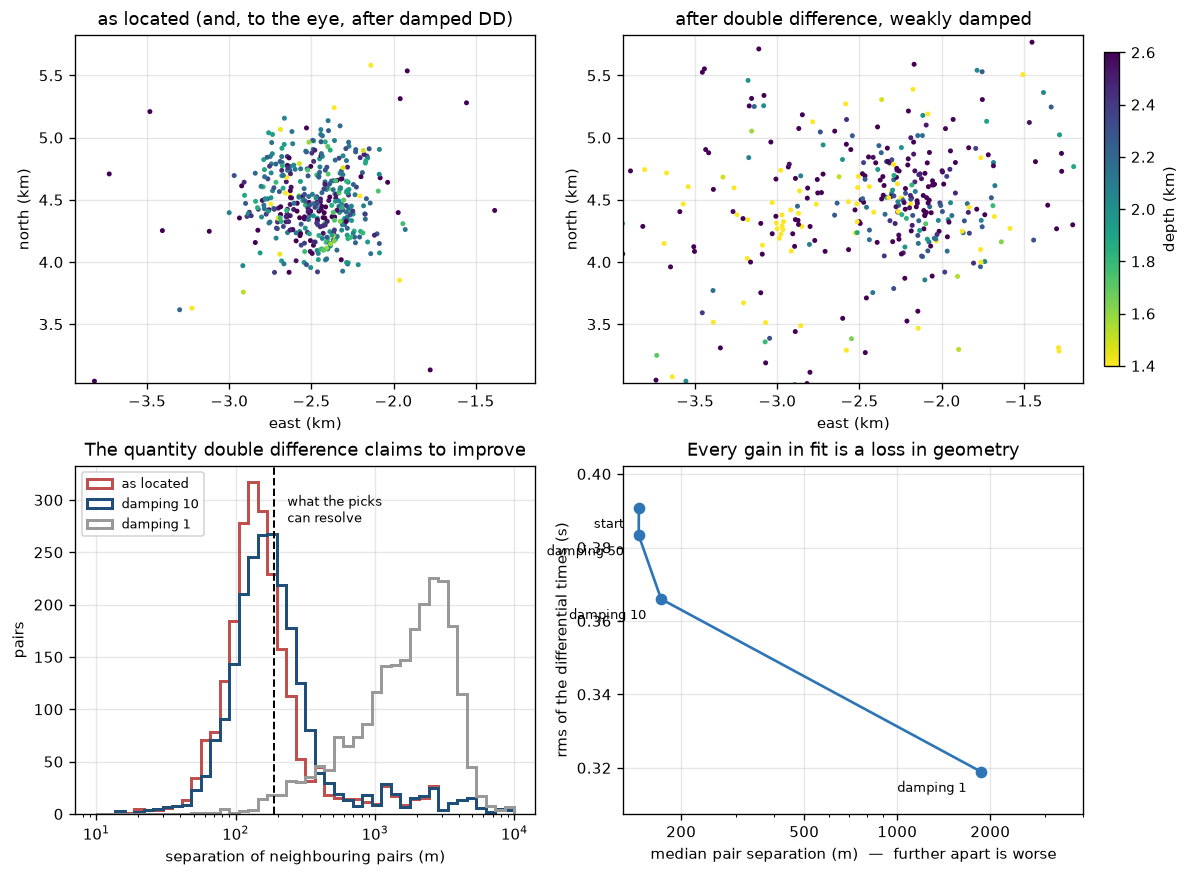

In [29]:
def pair_seps(A):
    return 1000 * np.array([np.linalg.norm(A[i, :3] - A[j, :3]) for i, j, *_ in PAIR])


fig, ax = plt.subplots(2, 2, figsize=(9.8, 7.2), constrained_layout=True)
ext = [M_start[:, 0].mean() - 1.4, M_start[:, 0].mean() + 1.4,
       M_start[:, 1].mean() - 1.4, M_start[:, 1].mean() + 1.4]
for a, A, lab in ((ax[0, 0], M_start, "as located (and, to the eye, after damped DD)"),
                  (ax[0, 1], runs[1.0], "after double difference, weakly damped")):
    s = a.scatter(A[:, 0], A[:, 1], c=A[:, 2], s=9, cmap="viridis_r", vmin=1.4, vmax=2.6,
                  linewidths=0)
    a.set(xlim=ext[:2], ylim=ext[2:], xlabel="east (km)", ylabel="north (km)", title=lab)
fig.colorbar(s, ax=ax[0].tolist(), location="right", label="depth (km)", shrink=0.9, pad=0.02)

bins = np.logspace(1, 4, 45)
for A, lab, c in ((M_start, "as located", "#c0504d"), (runs[10.0], "damping 10", "#1f4e79"),
                  (runs[1.0], "damping 1", "#999999")):
    ax[1, 0].hist(pair_seps(A), bins=bins, histtype="step", lw=1.8, color=c, label=lab)
res_m = 1000 * sig_pick * np.sqrt(2) * v[0]
ax[1, 0].axvline(res_m, c="k", ls="--", lw=1.2)
ax[1, 0].text(res_m * 1.25, ax[1, 0].get_ylim()[1] * 0.92, "what the picks\ncan resolve",
              fontsize=7.5, va="top")
ax[1, 0].set(xscale="log", xlabel="separation of neighbouring pairs (m)", ylabel="pairs",
             title="The quantity double difference claims to improve")
ax[1, 0].legend(fontsize=7.5, loc="upper left")

pts = [("start", M_start)] + [(f"damping {d:g}", runs[d]) for d in (50.0, 10.0, 1.0)]
xs = [np.median(pair_seps(A)) for _, A in pts]
ys = [dd_rms(A) for _, A in pts]
ax[1, 1].plot(xs, ys, "o-", c="#2e75b6", lw=1.6)
for (lab, _), x, y in zip(pts, xs, ys):
    ax[1, 1].annotate(lab, (x, y), (-9, -12), textcoords="offset points", fontsize=7.5,
                      ha="right")
ax[1, 1].set(xscale="log", xlim=(130, 4000), xticks=[200, 500, 1000, 2000],
             xticklabels=["200", "500", "1000", "2000"],
             xlabel="median pair separation (m)  —  further apart is worse",
             ylabel="rms of the differential times (s)",
             title="Every gain in fit is a loss in geometry")
ax[1, 1].xaxis.set_minor_formatter(plt.NullFormatter())   # log minor labels collide with ours
ax[1, 1].margins(y=0.16)
plt.show()


## B.7 · Which earthquakes can you trust?

Everything so far has been a statement about the catalogue as a whole: the *median* earthquake
ends up a couple of hundred metres from the network's answer. That is the least useful thing we
can say, because nobody ever interprets the median earthquake. They interpret a particular one —
the one on the fault they care about — and what they need to know is whether *that* one is good.

A.13 listed eight factors that decide where an earthquake ends up. The ladder tested the ones we
get to **choose**: the velocity model, the loss, the station terms, the weights. Three of the
eight are not choices at all. They are properties of the data each earthquake happens to have:

* **how many picks** recorded it;
* **how those picks surround it** — the azimuthal gap;
* **how well the arrivals could be read**, which here we see only through the weight codes the
  analyst wrote down.

Part A varied all three against a planted truth. This section varies them on the real picks, and
then asks the question they exist to answer: **when you hand someone a hypocentre and an error
bar, does the error bar tell them which earthquakes to keep?** That is the single most useful
thing this session can give you for the final project, where you will have to choose.


In [30]:
def locate_with_error(p, tabs, terms, sigma=SIGMA):
    """Locate every event, keeping its formal covariance and the geometry of its own recording."""
    dt = pd.Series(terms).reindex(p.sta_key.to_numpy()).fillna(0.0).to_numpy()
    w = p.phase_score.to_numpy()
    out, dropped = [], []
    for eid, g in p.groupby("eid", sort=False):
        i = g.index.to_numpy()
        S = g[["x", "y", "z"]].to_numpy()
        r = gl.locate(S, g.tsec.to_numpy(), g.ph.to_numpy(), tabs,
                      x0=[S[:, 0].mean(), S[:, 1].mean(), 2.0, 0.0], loss="huber",
                      sigma=sigma, terms=dt[i], pick_w=w[i])
        res = r["res"]
        # A.8's sigma^2 (J^T J)^-1, twice: once with sigma from every residual, and once with a
        # sigma that ignores the outliers the Huber loss already ignored. Same fit, same location.
        mad = 1.4826 * np.median(np.abs(res - np.median(res)))
        C, Cr = gl.ellipse(r), gl.ellipse(r, sigma=max(mad, 1e-3))
        # A Jacobian that is singular, or nearly so, gives no usable ellipse. That happens to a
        # handful of events whose picks are almost collinear in the four unknowns -- the extreme
        # of A.5's condition number -- and those events are set aside rather than plotted as NaN.
        if not (np.all(np.isfinite(np.diag(C))) and np.all(np.diag(C) > 0)
                and np.all(np.isfinite(np.diag(Cr))) and np.all(np.diag(Cr) > 0)):
            dropped.append(eid)
            continue
        az = np.degrees(np.arctan2(S[:, 0] - r["m"][0], S[:, 1] - r["m"][1])) % 360
        u = np.unique(np.round(az, 2))          # one azimuth per station, not per pick
        gap = float(np.max(np.diff(np.append(u, u[0] + 360)))) if len(u) > 1 else 360.0
        out.append((eid, *r["m"], np.hypot(np.sqrt(C[0, 0]), np.sqrt(C[1, 1])), np.sqrt(C[2, 2]),
                    np.sqrt(Cr[0, 0]), np.sqrt(Cr[1, 1]), np.sqrt(Cr[2, 2]), Cr[0, 1],
                    len(g), gap, float(np.mean(g.phase_score))))
    if dropped:
        print(f"{len(dropped)} of {p.eid.nunique()} events have a singular Jacobian and no "
              f"usable error bar; they are set aside")
    return pd.DataFrame(out, columns=["eid", "x", "y", "z", "t0", "sh_all", "sz_all",
                                      "sx", "sy", "sz", "cxy", "npick", "gap", "score"]
                        ).set_index("eid")


# The same 1,200 earthquakes the ladder used. They are drawn again here rather than carried over,
# because B.4 reused the name `sub` for a smaller subset of its own.
pop = picks[picks.eid.isin(np.random.default_rng(0).choice(cat.index.values, 1200, replace=False))
            ].reset_index(drop=True)
ev = locate_with_error(pop, tab_gey, terms_by["+ the analyst's pick weights"])
e = cat.loc[ev.index]
ev["dh"] = np.hypot(ev.x - e.x, ev.y - e.y)    # how far we ended up from the network's answer
ev["adz"] = (ev.z - e.depth).abs()
ev["sh"] = np.hypot(ev.sx, ev.sy)              # our own formal horizontal error bar
print(f"{len(ev):,} earthquakes, each with its own error bar and its own recording geometry")
print(f"median distance from the catalogue : {1000 * ev.dh.median():.0f} m horizontal, "
      f"{1000 * ev.adz.median():.0f} m in depth")
print(f"picks per event  {ev.npick.min():.0f} to {ev.npick.max():.0f}      "
      f"azimuthal gap  {ev.gap.min():.0f}° to {ev.gap.max():.0f}°")


1 of 1200 events have a singular Jacobian and no usable error bar; they are set aside
1,199 earthquakes, each with its own error bar and its own recording geometry
median distance from the catalogue : 190 m horizontal, 372 m in depth
picks per event  8 to 64      azimuthal gap  37° to 338°


### The three things we do not get to choose

Each table splits those 1,200 earthquakes into four equal groups and reports how far the group
sits from the network's answer. **Nothing about the method changes between rows** — same model,
same loss, same station terms, same weights. The only difference is what the network recorded.


In [31]:
def split_by(col, label, fmt="{:.0f}"):
    for k, d in ev.groupby(pd.qcut(ev[col], 4, duplicates="drop"), observed=True):
        print(f"   {fmt.format(k.left):>6} to {fmt.format(k.right):<8}{len(d):5d}"
              f"{d.dh.median():10.3f} km{d.adz.median():10.3f} km{1000 * d.sh.median():9.0f} m")


print(f"{'':22}{'events':>5}{'horizontal':>13}{'depth':>13}{'our error bar':>15}")
print("\npicks on the event")
split_by("npick", "picks")
print("\nazimuthal gap (degrees)")
split_by("gap", "gap")
print("\nmean declared weight of its picks")
split_by("score", "score", "{:.2f}")


                      events   horizontal        depth  our error bar

picks on the event
        8 to 10        316     0.282 km     0.531 km      176 m
       10 to 15        304     0.198 km     0.416 km      119 m
       15 to 28        281     0.181 km     0.409 km       83 m
       28 to 64        298     0.144 km     0.228 km       65 m

azimuthal gap (degrees)
       37 to 65        300     0.158 km     0.330 km       73 m
       65 to 82        300     0.180 km     0.342 km       91 m
       82 to 108       299     0.171 km     0.342 km      101 m
      108 to 338       300     0.288 km     0.506 km      175 m

mean declared weight of its picks
     0.50 to 0.69      300     0.216 km     0.336 km      103 m
     0.69 to 0.76      300     0.196 km     0.378 km      106 m
     0.76 to 0.82      307     0.179 km     0.356 km       97 m
     0.82 to 0.98      292     0.175 km     0.408 km       89 m


**All three matter, and none of them is negligible.** Going from the worst quarter to the best is
worth roughly a factor of two horizontally, and a comparable amount in depth — a large share of what
the entire improvement ladder of B.3 bought by choosing better methods. Much of the quality of a
catalogue is settled before anyone chooses a method at all, simply by which stations were running
when the earthquake happened.

The gap row deserves a second look. A.5 predicted that an open gap costs more than losing the
same number of picks, because what matters is not how much data you have but whether it
surrounds the thing you are locating — and here the gap table spans nearly the same factor as
the pick-count table. Part A varied these over ranges we chose, while the real network hands us
the ranges it hands us, so the two experiments cannot be ranked against each other. What
transfers is the direction and the rough size, and both do.

The declared-weight row is the weakest of the three, and that is expected rather than
disappointing: the locator has **already** used those weights — they were the ladder's last
rung — so what is left here is the residual effect on events whose picks were poor even after
being down-weighted.


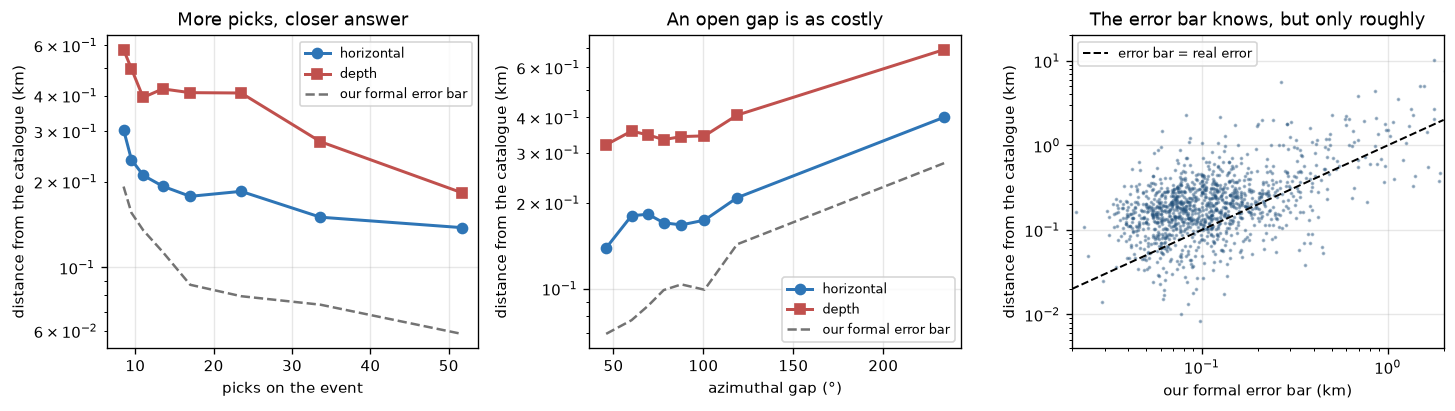

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(12.2, 3.5))
for a, col, lab, ttl in zip(ax[:2], ("npick", "gap"),
                            ("picks on the event", "azimuthal gap (°)"),
                            ("More picks, closer answer", "An open gap is as costly")):
    g = ev.groupby(pd.qcut(ev[col], 8, duplicates="drop"), observed=True)
    x = [i.mid for i in g.groups]
    a.plot(x, g.dh.median(), "o-", c="#2e75b6", lw=1.8, label="horizontal")
    a.plot(x, g.adz.median(), "s-", c="#c0504d", lw=1.8, label="depth")
    a.plot(x, g.sh.median(), "--", c="0.45", lw=1.5, label="our formal error bar")
    a.set(xlabel=lab, ylabel="distance from the catalogue (km)", yscale="log", title=ttl)
    a.legend(fontsize=7.5)

ax[2].loglog(ev.sh, ev.dh, ".", ms=2.5, c="#1f4e79", alpha=0.35)
lim = np.array([0.02, 2.0])
ax[2].plot(lim, lim, c="k", lw=1.2, ls="--", label="error bar = real error")
ax[2].set(xlim=lim, ylim=(0.004, 20), xlabel="our formal error bar (km)",
          ylabel="distance from the catalogue (km)",
          title="The error bar knows, but only roughly")
ax[2].legend(fontsize=7.5, loc="upper left")
fig.tight_layout()
plt.show()


### The error bar is not a fourth thing to check — it is the summary of the other three

The dashed grey line in the first two panels tracks the real error in both of them. That is
worth pausing on: the error bar is computed from the fit alone and has never seen the catalogue,
yet it moves the right way as the recording geometry changes. So we can ask which single number
best predicts that an earthquake is badly located.


In [33]:
r = ev[["npick", "gap", "score", "sh", "dh"]].corr(method="spearman")["dh"]
print("how well each number predicts the real error (rank correlation):")
for k, lab in (("npick", "picks on the event"), ("gap", "azimuthal gap"),
               ("score", "mean declared weight"), ("sh", "our formal error bar")):
    print(f"   {lab:26}{r[k]:+6.2f}")
n4 = len(ev) // 4
tight, loose = ev.nsmallest(n4, "sh"), ev.nlargest(n4, "sh")
print(f"\nthe quarter with the smallest error bars sit {tight.dh.median():.3f} km from the "
      f"catalogue;\nthe quarter with the largest sit {loose.dh.median():.3f} km — a factor of "
      f"{loose.dh.median() / tight.dh.median():.1f}, wider than any single factor above separates.")


how well each number predicts the real error (rank correlation):
   picks on the event         -0.34
   azimuthal gap              +0.30
   mean declared weight       -0.17
   our formal error bar       +0.44

the quarter with the smallest error bars sit 0.139 km from the catalogue;
the quarter with the largest sit 0.330 km — a factor of 2.4, wider than any single factor above separates.


**The formal error bar beats every individual property of the recording**, because it is the one
quantity that combines them: the number of picks, their geometry and how well they fit all enter
σ²(JᵀJ)⁻¹ together. That is the practical rule to take to the project. *Do not filter a
catalogue on pick count or on azimuthal gap. Filter it on the error bar, which already knows
about both.*

But look at the size of that rank correlation before trusting it too far. It is a useful
ordering, not a strong one: plenty of events with small error bars still sit far from the
network's answer, and the third panel shows the cloud is wide. An error bar sorts a catalogue;
it does not certify an earthquake.

### How big is the error bar? That depends on a choice nobody can make for you

A.8 said that an error bar computed from a fit describes the noise you *assumed*, not the error
you *have*. Here is that sentence as an experiment. We just computed the same ellipse twice, from
the identical fit and the identical location, differing only in how σ was estimated from the
residuals: once over all of them, once over the ones the Huber loss did not already discard.


In [34]:
print(f"{'sigma estimated from':34}{'median error bar':>18}{'10th':>9}{'90th':>9}")
for lab, col in (("every residual", "sh_all"), ("the residuals Huber kept", "sh")):
    s = ev[col]
    print(f"{lab:34}{1000 * s.median():15.0f} m{1000 * s.quantile(.1):8.0f}"
          f"{1000 * s.quantile(.9):9.0f}")
print(f"\nthe two differ by a factor of {ev.sh_all.median() / ev.sh.median():.1f} on the median "
      f"event, while the hypocentre is identical.")
print(f"and the second ranks the events better: rank correlation with the real error "
      f"{ev[['sh_all', 'dh']].corr(method='spearman').iloc[0, 1]:.2f} against "
      f"{ev[['sh', 'dh']].corr(method='spearman').iloc[0, 1]:.2f}")


sigma estimated from                median error bar     10th     90th
every residual                                479 m      81     3393
the residuals Huber kept                      100 m      50      330

the two differ by a factor of 4.8 on the median event, while the hypocentre is identical.
and the second ranks the events better: rank correlation with the real error 0.31 against 0.44


**A factor of four in the published uncertainty, and not one metre of difference in the
published location.** Nothing in the data decides between them — it is the same modelling choice
as the loss function in A.6, made again and usually made silently. If you ever compare the error
bars of two catalogues, this is the first thing to establish about them.

### The nearest thing to A.9's coverage test that real data allow

A.9 could count how often the 95 % ellipse contained the truth, because Part A planted the
truth. Here there is none. What we *can* do is a consistency test. Our solution and the
network's are two estimates of the same quantity, each with a stated error. If both were
unbiased and both error bars honest, the gap between them should fall inside the combined 95 %
region about 95 % of the time.


In [35]:
dx, dy = (ev.x - e.x).to_numpy(), (ev.y - e.y).to_numpy()
cat_h = e.horizontalError.to_numpy() ** 2 / 2.0        # split isotropically between the two axes
Cx = ev.sx.to_numpy() ** 2 + cat_h
Cy = ev.sy.to_numpy() ** 2 + cat_h
Cxy = ev.cxy.to_numpy()
q = (dx ** 2 * Cy - 2 * dx * dy * Cxy + dy ** 2 * Cx) / (Cx * Cy - Cxy ** 2)
sz = np.sqrt(ev.sz.to_numpy() ** 2 + e.depthError.to_numpy() ** 2)
dz = (ev.z - e.depth).to_numpy()
print(f"{'':46}{'nominal':>10}{'actual':>9}")
print(f"{'disagreement inside the combined horizontal region':46}{'95 %':>10}"
      f"{100 * np.mean(q < 5.991):8.0f} %")
print(f"{'disagreement inside the combined depth interval':46}{'95 %':>10}"
      f"{100 * np.mean(np.abs(dz) < 1.96 * sz):8.0f} %")
print(f"\nmost of that budget is the catalogue's, not ours: its stated errors are "
      f"{e.horizontalError.median():.2f} km horizontal and {e.depthError.median():.2f} km in "
      f"depth,\nagainst our {1000 * ev.sh.median():.0f} m and {1000 * ev.sz.median():.0f} m.")
understated = float(ev.dh.median() / ev.sh.median())
print(f"\nso the decidable half of the question: OUR error bar would have to be "
      f"{understated:.1f}x larger to cover")
print(f"the typical disagreement with the network, while the network's stated "
      f"{e.horizontalError.median():.2f} km already does.")


                                                 nominal   actual
disagreement inside the combined horizontal region      95 %      93 %
disagreement inside the combined depth interval      95 %      93 %

most of that budget is the catalogue's, not ours: its stated errors are 0.28 km horizontal and 0.52 km in depth,
against our 100 m and 125 m.

so the decidable half of the question: OUR error bar would have to be 1.9x larger to cover
the typical disagreement with the network, while the network's stated 0.28 km already does.


**The two solutions are consistent with each other — and that settles nothing about either
one.** This is the most important sentence in Part B, so it is worth being slow about.

A.9 produced a catalogue that was wrong by a kilometre in depth while its error ellipses stayed
the right shape, because a wrong velocity model moves *every* event the same way. Our solution
and the network's were computed **with the same velocity model**. So whatever that model gets
wrong, it gets wrong for both of us, identically — and it cancels exactly in the difference we
just tested. The test is blind, by construction, to the one error A.13 ranked first.

What it can see is the part where we differ: different loss, different station terms, different
treatment of elevation. On that part we agree, comfortably — and that much of prediction 5 *is*
decidable, with a split verdict. Our own formal ellipse is the optimistic one: it would have to
be nearly twice as wide to account for a disagreement caused by nothing more exotic than two
codes making different reasonable choices. The network's published error is not optimistic in
that sense at all; it covers the disagreement with room to spare. A reader who stopped here would
conclude that these hypocentres are good to a couple of hundred metres, and would be making
precisely the mistake A.9 exists to prevent.

For the size of the error the test cannot see, look back at B.4: moving the datum across its
defensible range shifted every depth by more than our disagreement with the network. **The
thing both catalogues share moves them further than the thing they differ on.**

And that is the whole reason Part A had to be synthetic. *Coverage is not measurable on real
data.* Any check you can run against a published catalogue compares two estimates that lean on
the same physics, and will report agreement whether or not either is near the Earth.


## B.8 · What may be interpreted

B.7 left the problem in its sharpest form. Our locations and the network's agree to within the
errors both of us state — and that agreement is close to uninformative, because the error that
matters most is the one we share. B.4 put a size on it: a defensible change of datum, or a few
per cent on the velocity model, moves every depth further than the two catalogues differ from
each other.

So the question to close on is not "how good are these locations" but **which features of them
would survive someone repeating the work differently?**

The map below is the standing practice for answering that: the same earthquakes, located every
way we have, on the same axes.


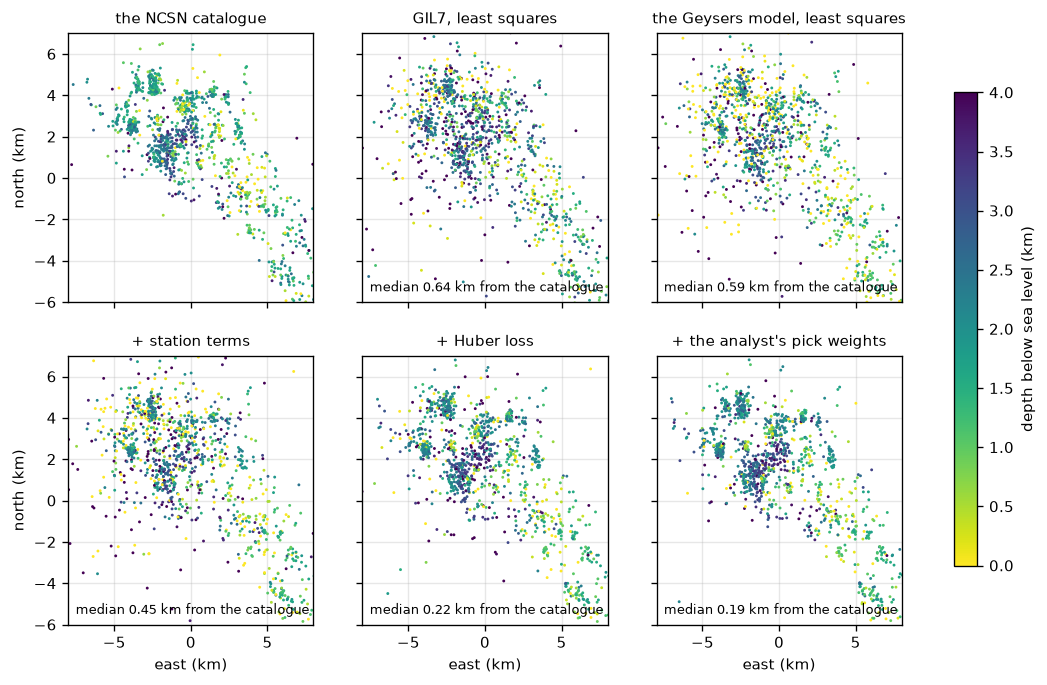

In [36]:
LAB = ["GIL7, least squares", "the Geysers model, least squares", "+ station terms",
       "+ Huber loss", "+ the analyst's pick weights"]
ids = results[LAB[0]].index
c = cat.loc[ids]
panels = [("the NCSN catalogue", c.x.to_numpy(), c.y.to_numpy(), c.depth.to_numpy())]
for k in LAB:
    ev = results[k].loc[ids]
    panels.append((k, ev.x.to_numpy(), ev.y.to_numpy(), ev.z.to_numpy()))

fig, axes = plt.subplots(2, 3, figsize=(11.2, 6.4), sharex=True, sharey=True)
for ax, (lab, X, Y, Z) in zip(axes.ravel(), panels):
    s = ax.scatter(X, Y, c=Z, s=3, cmap="viridis_r", vmin=0, vmax=4, linewidths=0)
    ax.set_title(lab, fontsize=9)
    if lab != "the NCSN catalogue":
        d = np.hypot(X - c.x.to_numpy(), Y - c.y.to_numpy())
        ax.text(0.03, 0.04, f"median {np.median(d):.2f} km from the catalogue",
                transform=ax.transAxes, fontsize=7.5)
for ax in axes[1]:
    ax.set_xlabel("east (km)")
for ax in axes[:, 0]:
    ax.set_ylabel("north (km)")
axes[0, 0].set(xlim=(-8, 8), ylim=(-6, 7))
fig.colorbar(s, ax=axes, label="depth below sea level (km)", shrink=0.8)
plt.show()


### What survives, and what does not

**The structure survives, and its sharpness does not.** The southeastern arm of seismicity is
visible in every panel, including the one made with the wrong velocity model — it is a feature of
the arrival times, not of our choices, and it can be interpreted. The main northwest band is
smeared into a cloud in the GIL7 panel and crisp in the last one: the same structure, recovered
with very different fidelity.

That distinction is the whole practical point. Anyone who measured the *width* of that band, or
counted how many strands it has, from the second panel and from the last would report two
different structures — and neither width is a property of the Earth alone. What can be read off
these maps is where the seismicity is and roughly how it trends; what cannot is how thin it is.

**The depth is the least transferable number of all.** B.3 moved every depth half a kilometre by
changing the velocity model, B.4 moved them several hundred metres more by changing the datum,
and several hundred more again by slowing the model — every one of them while the fit stayed
essentially as good.

So the honest summary of what this session produced is: *the shape is real, the sharpness is a
property of the method, and the absolute position — especially in depth — is a property of the
velocity model.*


In [37]:
print("the nine predictions Part A made, and what the 2016 Geysers picks did:\n")
checks = [
    ("1. a coarse search is needed to seed the iteration",
     "yes — without it B.2 lands elsewhere on one event in eight, and fits worse when it does"),
    ("2. depth is the fragile number; the dense network rescues it",
     f"yes — the catalogue's own depth error ({cat.depthError.median():.2f} km) is twice its "
     f"horizontal one ({cat.horizontalError.median():.2f} km)"),
    ("3. a robust loss is a large rung of the ladder",
     f"yes — Huber alone moved the median from {rows[2][1]['dh']:.2f} to {rows[3][1]['dh']:.2f} km"),
    ("4. declared pick weights act mostly on the worst events",
     f"yes — median improved {rows[3][1]['dh'] / rows[4][1]['dh']:.1f}x, "
     f"90th percentile {rows[3][1]['dh90'] / rows[4][1]['dh90']:.1f}x"),
    ("5. the catalogue's quoted errors are optimistic",
     f"split — OUR ellipse is ({understated:.1f}x too small); the network's covers the "
     f"disagreement, and neither sees the model error they share (B.7)"),
    ("6. the velocity model shows up as depth bias, not misfit",
     f"yes — GIL7 shifts the depth {abs(rows[0][1]['dz'] - rows[1][1]['dz']):.2f} km and "
     f"the epicentre {abs(rows[0][1]['dh'] - rows[1][1]['dh']):.2f} km"),
    ("7. station terms transfer to events they were not fitted on",
     "yes — out of sample as good as in sample (B.5)"),
    ("8. double difference on catalogue picks adds little",
     "yes, and more sharply: the differential times cannot resolve the cluster at all (B.6)"),
    ("9. a 1-D model cannot be fitted with the hypocentres free",
     f"yes — B.4 pushes every event {1000 * max(trade):.0f} m deeper and the fit survives on a "
     f"model {100 * (1 - trade[max(trade)][1]):.0f} % slower"),
]
w = max(len(a) for a, _ in checks)
for a, b in checks:
    print(f"  {a:<{w}}   {b}")


the nine predictions Part A made, and what the 2016 Geysers picks did:

  1. a coarse search is needed to seed the iteration             yes — without it B.2 lands elsewhere on one event in eight, and fits worse when it does
  2. depth is the fragile number; the dense network rescues it   yes — the catalogue's own depth error (0.51 km) is twice its horizontal one (0.28 km)
  3. a robust loss is a large rung of the ladder                 yes — Huber alone moved the median from 0.45 to 0.22 km
  4. declared pick weights act mostly on the worst events        yes — median improved 1.1x, 90th percentile 2.5x
  5. the catalogue's quoted errors are optimistic                split — OUR ellipse is (1.9x too small); the network's covers the disagreement, and neither sees the model error they share (B.7)
  6. the velocity model shows up as depth bias, not misfit       yes — GIL7 shifts the depth 0.56 km and the epicentre 0.05 km
  7. station terms transfer to events they were not fitted on    ye

A.13's other table — the eight factors that decide where an earthquake ends up — was checked in
B.7. The three of them we do not control (how many picks, how they surround the event, how well
they were read) each move a real location in the direction Part A measured and by roughly the
size it measured, and the formal error bar predicts the outcome better than any of them alone.

## Takeaways

**Machine learning.** Non-linear least squares is linear least squares relinearised, so week 1
carries over intact — but once the residuals have a heavy tail the loss function you choose moves
the answer further than any optimiser will, and an error bar computed from the fit describes only
the noise you assumed rather than the model error you have, which is why a confidence region is a
claim to be tested by counting how often it covers the truth and not a number simply to be
reported.

**Seismology.** An earthquake location is precise to a couple of hundred metres and accurate only
to whatever the velocity model is wrong by, which is why every serious relocation method spends
its effort on travel-time bias rather than on the hypocentre, and why the *shape* of a relocated
cluster may be interpreted while its *position*, above all its depth, may not.

**And one rule to carry into the project.** When you have to decide which earthquakes of a
catalogue to keep, filter on the formal error bar rather than on pick count or azimuthal gap:
B.7 measured it to be the better predictor of the two, because it is the one number that already
combines them. Then remember what it cannot do, and do not read it as a distance to the Earth.

### The recipe, for when you do this yourself

Everything above collapses into seven decisions, and the final project will ask you to make all
of them on data of your own.

| the decision | what this session measured | where |
|---|---|---|
| **velocity model** | use the network's own. A respectable regional model costs half a kilometre of depth and nothing in fit, so the fit will not warn you | B.2, B.3 |
| **datum** | state it. A `CRH`-based catalogue reports depth below the mean station elevation, not below sea level, and the difference here is comparable to the reservoir's thickness | B.4 |
| **starting point** | grid search, then Levenberg–Marquardt. A fixed start is in a different basin on one event in eight | B.2 |
| **loss** | Huber, with σ at one to two times the reading error — here `SIGMA = 0.05` s. It is the largest single improvement for the typical earthquake, and a σ set too loose gives the tail back | B.3 |
| **pick weights** | use the codes the analyst assigned when reading the arrival, never a catalogue's post-fit weights, which were computed from the answer you are trying to reproduce | B.1, B.3 |
| **station terms** | fit them. They absorb the structure a 1-D model cannot carry, and they transfer to events they were not fitted on | B.3, B.5 |
| **which events to keep** | filter on the formal error bar, which already combines pick count, geometry and fit — not on any one of those | B.7 |

And one thing the recipe cannot give you: whether the result is near the Earth. That was A.9's
subject, and B.7 showed it cannot be settled against another catalogue.

---

**What comes next.** Session 4 asks which picks belong to which earthquake — association — and
does it by locating, reusing the forward model and Jacobian built today. Session 5 stops treating
the velocity model as given and solves for it. Session 6 measures differential times by
cross-correlation, which is the missing ingredient B.6 identified. Each of those is a direct
continuation of a limit we measured rather than a new subject.